# Step 1

# 에너지 사용량 예측 AI 모델

**데이터셋**: KAMP 자원 최적화 AI 데이터셋 (okm_augumented_2021.csv)  
**출처**: www.kamp-ai.kr  
**목표**: 15분 단위 피크 전력(kW) 예측 → 연간 기본 전기료 절감

---

### 모델링 프로세스 요약

**Target**: `15분` (15분 단위 최대수요전력, 단위: kW)

**1단계** 데이터 로드 및 기본 정보 확인 (.info / .describe)  
**2단계** EDA — 분포 시각화, 타겟 분포, 생산량-전력 관계  
**3단계** 결측치 / 이상치 확인 및 처리  
**4단계** 상관관계 분석 (Heatmap)  
**5단계** 변수 조합 설계 — Feature Set A / B / C  
**6단계** Train / Test Split + 스케일링  
**7단계** 모델 학습 — LinearReg / Ridge / DecisionTree / RandomForest / XGBoost / DNN  
**8단계** 하이퍼파라미터 튜닝 (GridSearchCV / RandomizedSearchCV)  
**9단계** 최종 모델 선정 및 종합 평가  
**10단계** 모델 저장 (pipeline.pkl)

# Step 2

In [3]:
import subprocess
import sys

required = {
    'xgboost'       : 'xgboost',
    'sklearn'       : 'scikit-learn',
    'pandas'        : 'pandas',
    'numpy'         : 'numpy',
    'matplotlib'    : 'matplotlib',
    'seaborn'       : 'seaborn',
    'joblib'        : 'joblib',
}

print("=== 라이브러리 설치 확인 ===\n")
for import_name, pkg_name in required.items():
    try:
        __import__(import_name)
        print(f"  ✅ {pkg_name:20s} 이미 설치됨")
    except ImportError:
        print(f"  ⚙️  {pkg_name:20s} 설치 중...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg_name, '--break-system-packages', '-q'])
        print(f"  ✅ {pkg_name:20s} 설치 완료")

print("\n✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!")

=== 라이브러리 설치 확인 ===

  ✅ xgboost              이미 설치됨
  ✅ scikit-learn         이미 설치됨
  ✅ pandas               이미 설치됨
  ✅ numpy                이미 설치됨
  ✅ matplotlib           이미 설치됨
  ✅ seaborn              이미 설치됨
  ✅ joblib               이미 설치됨

✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!


# 필요 라이브러리 설치 확인 (최초 1회만 실행)
# !pip install xgboost --break-system-packages
# !pip install scikit-learn --break-system-packages

# Step 3

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4
✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4


# Step 4

In [5]:
import os

# 현재 작업 디렉토리 확인
print(f"현재 작업 경로: {os.getcwd()}")

현재 작업 경로: c:\Users\Admin\hipython\ml


In [6]:
import os
import pandas as pd

# 가능한 경로 후보 목록
candidates = [
    r'C:\Users\Admin\hipython\data\okm_augumented_2021.csv',
    r'C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv',
    './data/okm_augumented_2021.csv',
]

# 존재하는 경로 자동 탐지
file_path = None
for path in candidates:
    if os.path.exists(path):
        file_path = path
        print(f"✅ 파일 발견: {file_path}")
        break

if file_path is None:
    print("❌ 파일을 찾지 못했습니다. 경로를 확인하세요.")
    print(f"   현재 작업 경로: {os.getcwd()}")
else:
    df = pd.read_csv(file_path)
    print(f"\n✅ 데이터 로드 완료")
    print(f"   행(row) 수 : {df.shape[0]:,}")
    print(f"   열(col) 수 : {df.shape[1]}")
    print()
    print("=== 컬럼 목록 ===")
    print(df.columns.tolist())
    print()
    print("=== 상위 5행 ===")
    display(df.head())

✅ 파일 발견: C:\Users\Admin\hipython\data\okm_augumented_2021.csv

✅ 데이터 로드 완료
   행(row) 수 : 6,168
   열(col) 수 : 18

=== 컬럼 목록 ===
['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

=== 상위 5행 ===


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


# Step 5

In [7]:
print("=== .info() — 컬럼별 타입 및 결측치 ===")
df.info()

=== .info() — 컬럼별 타입 및 결측치 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


# Step 6

In [8]:
print("=== .describe() — 기술통계 ===")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

=== .describe() — 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
날짜,6168.000000,20210492.299611,244.775577,20210101.000000,20210306.000000,20210509.000000,20210712.000000,20210914.000000
시간,6168.000000,12.428016,12.847309,0.000000,6.000000,12.000000,18.000000,188.000000
15분,6168.000000,90.410182,55.349403,0.000000,23.000000,101.000000,133.000000,207.000000
30분,6168.000000,92.695363,57.942122,0.000000,23.000000,104.000000,143.000000,222.000000
45분,6168.000000,95.106355,59.285709,0.000000,23.000000,105.000000,149.000000,218.000000
60분,6168.000000,95.037938,59.347554,0.000000,23.000000,107.000000,149.000000,214.000000
평균,6168.000000,93.424125,57.355938,0.000000,23.000000,104.000000,144.000000,208.000000
생산량,6168.000000,467.344682,857.571815,0.000000,0.000000,45.000000,637.250000,9830.000000
기온,6168.000000,15.906064,9.160356,-12.000000,9.600000,17.400000,23.300000,33.400000
풍속,6165.000000,2.063633,1.164118,0.000000,1.200000,1.900000,2.800000,7.600000


# Step 7

In [9]:
print("=== 결측치 현황 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측률(%)': missing_pct
}).query('`결측치 수` > 0')

print(missing_df)
print(f"\n총 결측치 수 : {missing.sum()}개")
print(f"결측치 있는 컬럼 : {len(missing_df)}개")

=== 결측치 현황 ===
      결측치 수  결측률(%)
풍속        3    0.05
강수량       1    0.02
공장인원     17    0.28

총 결측치 수 : 21개
결측치 있는 컬럼 : 3개


# Step 8

=== 이상치 확인 ===
[시간] 최대값: 188  (정상: 0~23)
       시간 > 23 인 행: 48건

[15분 피크전력] 최소: 0 / 최대: 207 / 평균: 90.4
                피크전력 = 0 인 행: 19건

[생산량] 0인 행: 2657건 (43.1%)  ← 비가동 시간

[공장인원] 최소: 0.00 / 최대: 48.39



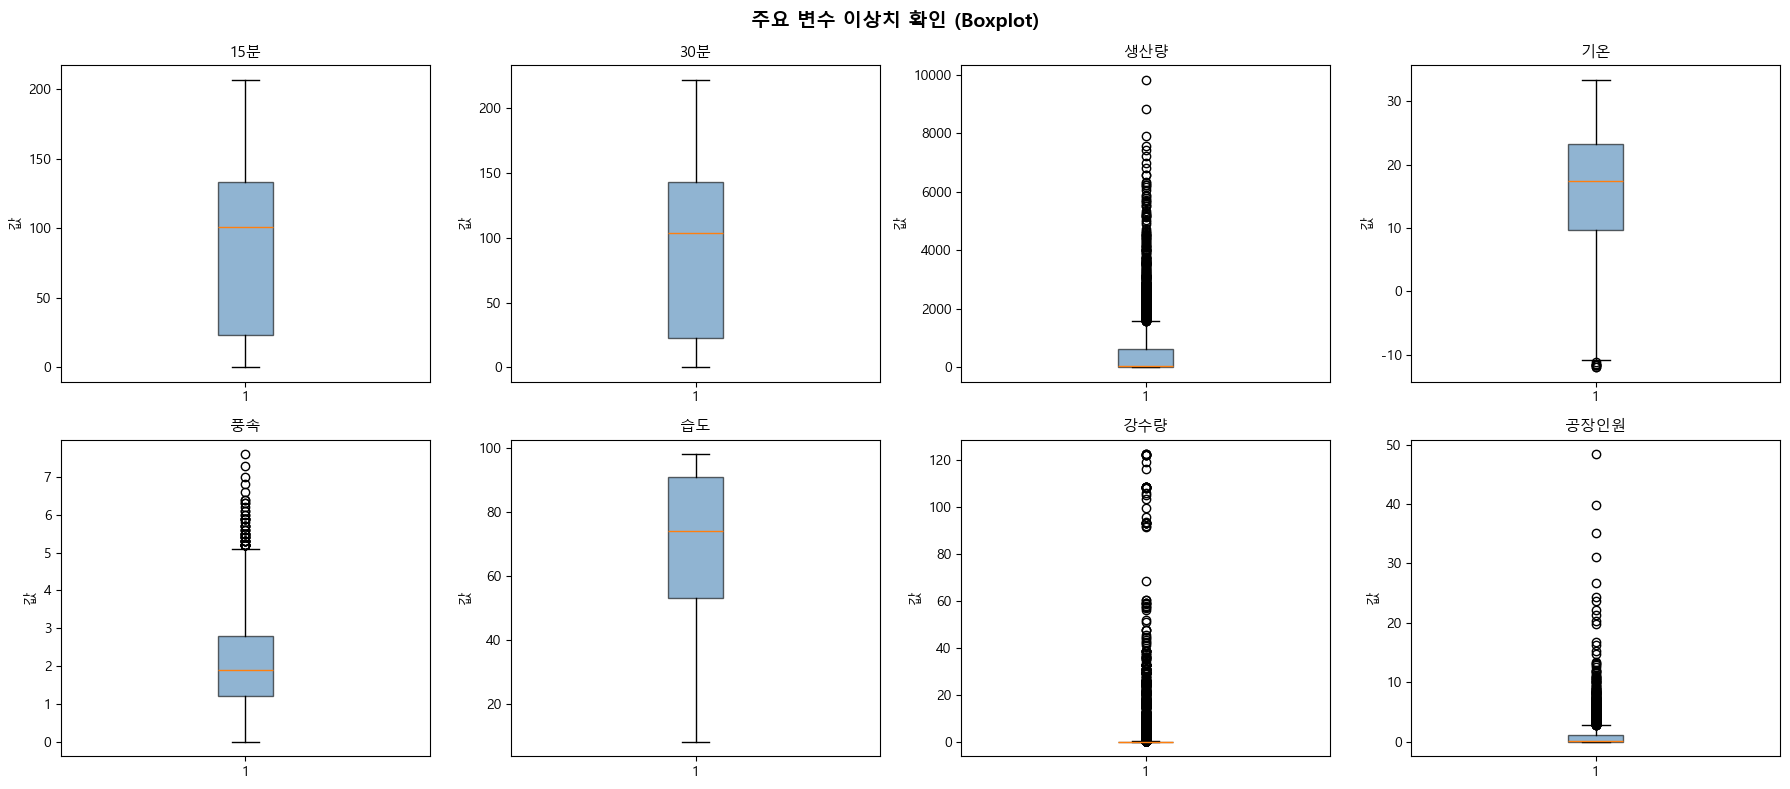

In [10]:
print("=== 이상치 확인 ===")

# 1) 시간 컬럼: 0~23이 정상
print(f"[시간] 최대값: {df['시간'].max()}  (정상: 0~23)")
print(f"       시간 > 23 인 행: {(df['시간'] > 23).sum()}건")
print()

# 2) 타겟 변수 분포
print(f"[15분 피크전력] 최소: {df['15분'].min()} / 최대: {df['15분'].max()} / 평균: {df['15분'].mean():.1f}")
print(f"                피크전력 = 0 인 행: {(df['15분'] == 0).sum()}건")
print()

# 3) 생산량 0 비율
print(f"[생산량] 0인 행: {(df['생산량'] == 0).sum()}건 ({(df['생산량'] == 0).mean()*100:.1f}%)  ← 비가동 시간")
print()

# 4) 공장인원 분포
print(f"[공장인원] 최소: {df['공장인원'].min():.2f} / 최대: {df['공장인원'].max():.2f}")
print()

# 5) 박스플롯으로 수치 변수 이상치 시각화
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('주요 변수 이상치 확인 (Boxplot)', fontsize=14, fontweight='bold')

cols_to_check = ['15분', '30분', '생산량', '기온', '풍속', '습도', '강수량', '공장인원']
for ax, col in zip(axes.flatten(), cols_to_check):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('값')

plt.tight_layout()
plt.show()

# Step 9

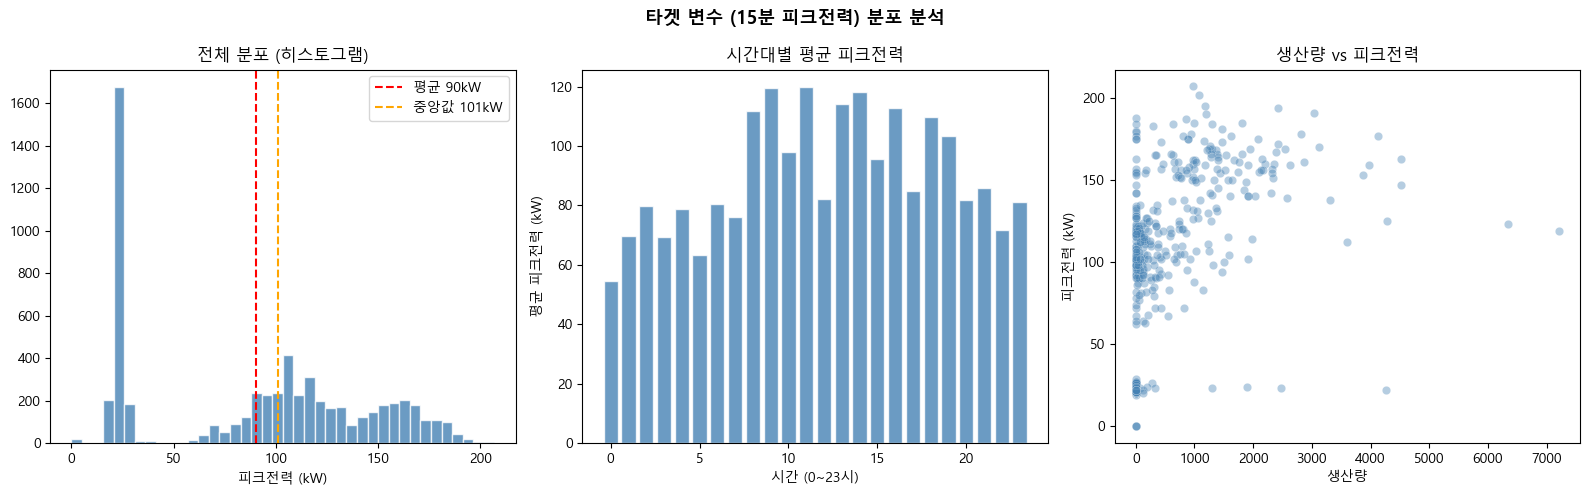


피크전력 고위험(≥130kW) 비율 : 26.9%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('타겟 변수 (15분 피크전력) 분포 분석', fontsize=13, fontweight='bold')

# 1) 히스토그램
axes[0].hist(df['15분'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['15분'].mean(),   color='red',    linestyle='--', label=f"평균 {df['15분'].mean():.0f}kW")
axes[0].axvline(df['15분'].median(), color='orange', linestyle='--', label=f"중앙값 {df['15분'].median():.0f}kW")
axes[0].set_title('전체 분포 (히스토그램)')
axes[0].set_xlabel('피크전력 (kW)')
axes[0].legend()

# 2) 시간대별 평균 피크전력
hourly = df[df['시간'] <= 23].groupby('시간')['15분'].mean()
axes[1].bar(hourly.index, hourly.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('시간대별 평균 피크전력')
axes[1].set_xlabel('시간 (0~23시)')
axes[1].set_ylabel('평균 피크전력 (kW)')

# 3) 생산량 vs 피크전력 산점도
sample = df[df['시간'] <= 23].sample(500, random_state=42)
axes[2].scatter(sample['생산량'], sample['15분'],
                alpha=0.4, color='steelblue', edgecolor='white', linewidth=0.3)
axes[2].set_title('생산량 vs 피크전력')
axes[2].set_xlabel('생산량')
axes[2].set_ylabel('피크전력 (kW)')

plt.tight_layout()
plt.show()

print(f"\n피크전력 고위험(≥130kW) 비율 : {(df['15분'] >= 130).mean()*100:.1f}%")

# Step 10

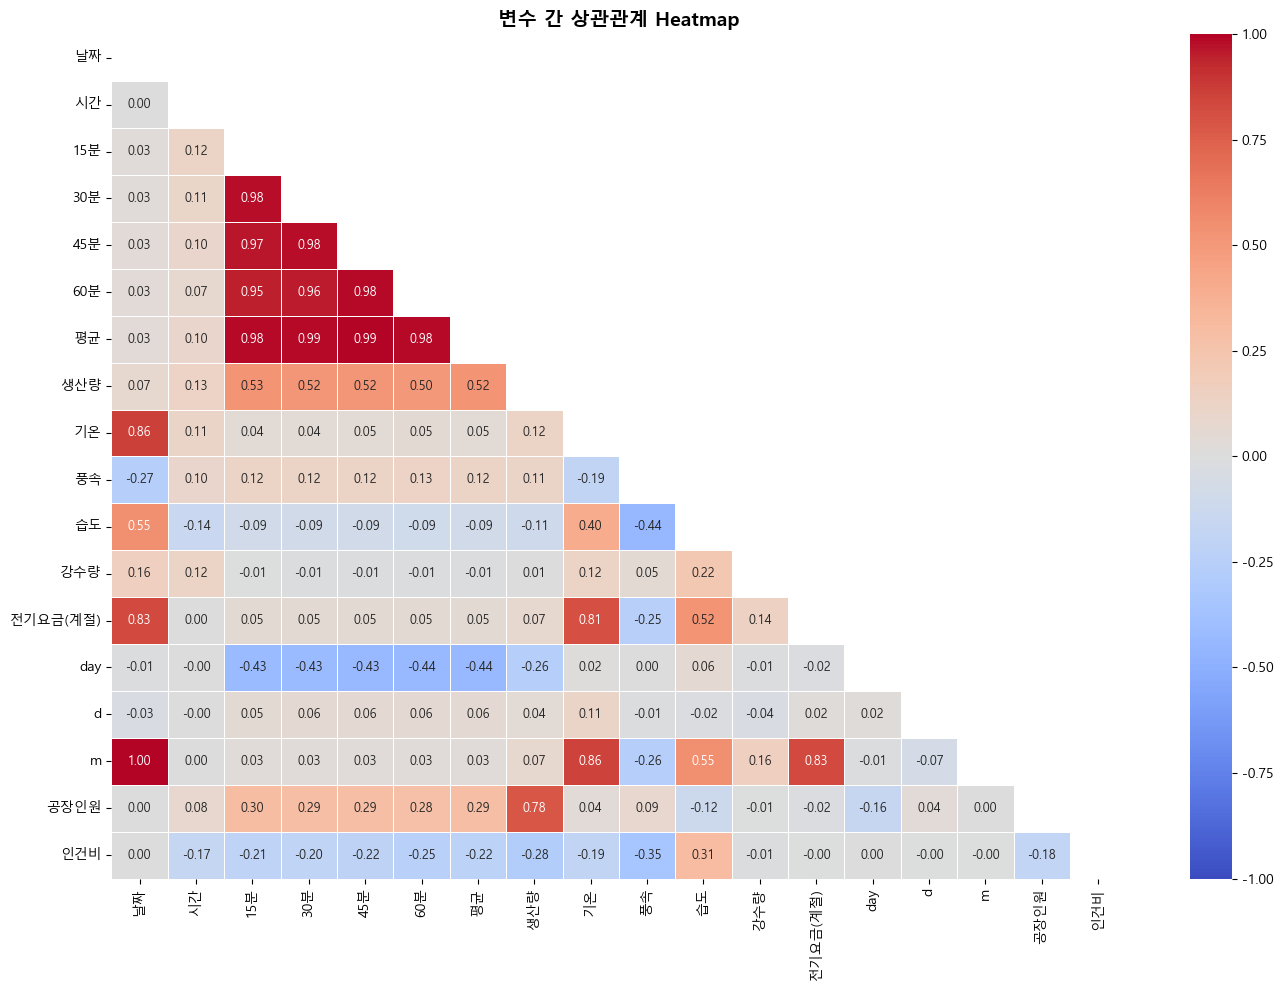

=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===
생산량         0.526266
day         0.427823
공장인원        0.299105
인건비         0.208396
시간          0.120790
풍속          0.119570
습도          0.089654
d           0.053607
전기요금(계절)    0.050699
기온          0.043692
날짜          0.030397
m           0.028410
강수량         0.006896


In [12]:
# 이상치 제거 후 상관관계 계산
df_corr = df[df['시간'] <= 23].copy()

# 상관행렬
corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('변수 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 타겟(15분)과의 상관계수 순위
print("=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===")
target_corr = corr_matrix['15분'].drop(['15분','30분','45분','60분','평균']).abs()
print(target_corr.sort_values(ascending=False).to_string())

# Step 11

In [13]:
# ── 전처리 ────────────────────────────────────────────
df_clean = df.copy()

# 1) 이상치 제거: 시간 > 23
before = len(df_clean)
df_clean = df_clean[df_clean['시간'] <= 23]
print(f"[이상치 제거] 시간>23: {before - len(df_clean)}행 제거 → 잔여 {len(df_clean):,}행")

# 2) 결측치 처리
df_clean['풍속']   = df_clean['풍속'].fillna(df_clean['풍속'].median())
df_clean['강수량']  = df_clean['강수량'].fillna(0)   # 강수 없음으로 대체
df_clean['공장인원'] = df_clean['공장인원'].fillna(0)  # 비가동으로 대체
print(f"[결측치 처리] 완료 — 남은 결측치: {df_clean.isnull().sum().sum()}개")

# 3) 타겟 / 피처 분리
# ※ 30분/45분/60분/평균은 Data Leakage → 반드시 제외
TARGET = '15분'
LEAK_COLS = ['30분', '45분', '60분', '평균']  # 타겟과 같은 계열 → 제외
DROP_COLS  = ['날짜'] + LEAK_COLS              # 날짜는 시계열 특성 대신 d/m으로 대체

feature_cols = [c for c in df_clean.columns if c not in [TARGET] + DROP_COLS]

X = df_clean[feature_cols].copy()
y = df_clean[TARGET].copy()

print(f"\n[피처 구성]")
print(f"  사용 피처 수 : {len(feature_cols)}개")
print(f"  피처 목록    : {feature_cols}")
print(f"\n  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"\n  타겟(y) 통계 → 평균: {y.mean():.1f}kW / 최대: {y.max()}kW / 최소: {y.min()}kW")

[이상치 제거] 시간>23: 48행 제거 → 잔여 6,120행
[결측치 처리] 완료 — 남은 결측치: 0개

[피처 구성]
  사용 피처 수 : 12개
  피처 목록    : ['시간', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

  X shape : (6120, 12)
  y shape : (6120,)

  타겟(y) 통계 → 평균: 90.1kW / 최대: 207kW / 최소: 0kW


# Step 12

## 변수 조합 설계 — Feature Set A / B / C

현실에서 공장 담당자가 **예측 시점에 알 수 있는 정보**만으로 피처를 구성합니다.

| Feature Set | 변수 구성 | 설명 |
|---|---|---|
| **Set A (핵심)** | 시간, 생산량, 공장인원, day, d, m | 공정 핵심 변수만 |
| **Set B (핵심+환경)** | Set A + 기온, 습도, 풍속, 강수량 | 날씨 변수 추가 |
| **Set C (전체)** | 전체 12개 변수 | 전기요금(계절), 인건비 포함 |

→ 3가지 Feature Set을 모두 학습해서 변수 추가 효과를 비교합니다.

# Step 13

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

print(f"\n✅ Split 완료")
print(f"   학습 데이터: {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")

=== Feature Set 구성 ===
  Set_A (6개): ['시간', '생산량', '공장인원', 'day', 'd', 'm']
  Set_B (10개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량']
  Set_C (12개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비']

✅ Split 완료
   학습 데이터: 4,896행
   테스트 데이터: 1,224행


# Step 14

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    """회귀 모델 성능 평가 지표 계산"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'모델': model_name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R²': round(r2,4)}

all_results = []   # 전체 결과 저장 리스트
print("✅ 평가 함수 정의 완료")

✅ 평가 함수 정의 완료


# Step 15

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

# ── 결과 저장 리스트 초기화 ───────────────────────────
all_results = []

print(f"\n✅ Split 완료")
print(f"   학습 데이터  : {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")
print(f"   all_results  : 초기화 완료")

=== Feature Set 구성 ===
  Set_A (6개): ['시간', '생산량', '공장인원', 'day', 'd', 'm']
  Set_B (10개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량']
  Set_C (12개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비']

✅ Split 완료
   학습 데이터  : 4,896행
   테스트 데이터: 1,224행
   all_results  : 초기화 완료


# Step 16

In [18]:
from sklearn.tree import DecisionTreeRegressor

print("=" * 55)
print("  [모델 3] Decision Tree Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    dt.fit(Xtr, y_train)
    res = evaluate_model(f'DecisionTree [{fs_name}]', y_test, dt.predict(Xte))
    all_results.append(res)
    print(f"  DecisionTree {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

print()
print("💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상")
print("   단, 단일 트리는 분기점에서 과적합 가능성 존재")
print("   → Random Forest(앙상블)로 개선 가능")

  [모델 3] Decision Tree Regressor
  DecisionTree Set_A  | RMSE= 16.89 | MAE=  9.45 | R²=0.9102
  DecisionTree Set_B  | RMSE= 18.50 | MAE= 10.26 | R²=0.8923
  DecisionTree Set_C  | RMSE= 18.51 | MAE= 10.28 | R²=0.8922

💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상
   단, 단일 트리는 분기점에서 과적합 가능성 존재
   → Random Forest(앙상블)로 개선 가능


# Step 17

In [19]:
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  [모델 4] Random Forest Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(Xtr, y_train)
    res = evaluate_model(f'RandomForest [{fs_name}]', y_test, rf.predict(Xte))
    all_results.append(res)
    print(f"  RandomForest {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장 (Feature Importance용)
rf_setC = RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_setC.fit(splits['Set_C']['X_train'], y_train)

print()
print("💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능")
print("   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제")

  [모델 4] Random Forest Regressor
  RandomForest Set_A  | RMSE= 13.07 | MAE=  7.53 | R²=0.9463
  RandomForest Set_B  | RMSE= 14.19 | MAE=  8.46 | R²=0.9366
  RandomForest Set_C  | RMSE= 14.26 | MAE=  8.47 | R²=0.9359

💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능
   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제


# Step 18

In [20]:
from xgboost import XGBRegressor

print("=" * 55)
print("  [모델 5] XGBoost Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb.fit(Xtr, y_train,
            eval_set=[(Xte, y_test)],
            verbose=False)
    res = evaluate_model(f'XGBoost [{fs_name}]', y_test, xgb.predict(Xte))
    all_results.append(res)
    print(f"  XGBoost {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장
xgb_setC = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0)
xgb_setC.fit(splits['Set_C']['X_train'], y_train, verbose=False)

print()
print("💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)")
print("   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습")
print("   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지")

  [모델 5] XGBoost Regressor
  XGBoost Set_A  | RMSE= 12.36 | MAE=  7.94 | R²=0.9519
  XGBoost Set_B  | RMSE= 13.20 | MAE=  8.30 | R²=0.9451
  XGBoost Set_C  | RMSE= 13.33 | MAE=  8.47 | R²=0.9441

💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)
   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습
   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지


# Step 19

In [21]:
from sklearn.neural_network import MLPRegressor

print("=" * 55)
print("  [모델 6] DNN (sklearn MLPRegressor)")
print("=" * 55)
print("  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용")
print()

dnn_configs = {
    'DNN-Shallow [64]'       : (64,),
    'DNN-Medium  [128,64]'   : (128, 64),
    'DNN-Deep    [128,64,32]': (128, 64, 32),
}

# Set_C 기준으로만 DNN 실행
Xtr_sc = splits['Set_C']['X_train_sc']
Xte_sc = splits['Set_C']['X_test_sc']

for dnn_name, layers in dnn_configs.items():
    dnn = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,       # 과적합 방지 자동 조기종료
        validation_fraction=0.1,   # train의 10%를 검증용으로 사용
        random_state=42
    )
    dnn.fit(Xtr_sc, y_train)
    res = evaluate_model(f'{dnn_name} [Set_C]', y_test, dnn.predict(Xte_sc))
    all_results.append(res)
    print(f"  {dnn_name} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")
    print(f"              → 실제 학습 에포크: {dnn.n_iter_}회 (early stopping)")

# 최적 DNN 저장 (Medium)
dnn_best = MLPRegressor(hidden_layer_sizes=(128,64), activation='relu',
                        solver='adam', max_iter=500, early_stopping=True,
                        validation_fraction=0.1, random_state=42)
dnn_best.fit(Xtr_sc, y_train)

print()
print("💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)")
print("   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습")
print("   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료")
print("   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음")
print("      (DNN은 수십만 행 이상에서 진가 발휘)")

  [모델 6] DNN (sklearn MLPRegressor)
  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용

  DNN-Shallow [64] | RMSE= 30.98 | MAE= 24.02 | R²=0.6979
              → 실제 학습 에포크: 500회 (early stopping)
  DNN-Medium  [128,64] | RMSE= 20.99 | MAE= 14.65 | R²=0.8613
              → 실제 학습 에포크: 354회 (early stopping)
  DNN-Deep    [128,64,32] | RMSE= 21.59 | MAE= 15.26 | R²=0.8532
              → 실제 학습 에포크: 168회 (early stopping)

💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)
   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습
   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료
   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음
      (DNN은 수십만 행 이상에서 진가 발휘)


# Step 20

In [22]:
results_df = pd.DataFrame(all_results)

print("=" * 65)
print("  전체 모델 × Feature Set 비교표 (R² 내림차순)")
print("=" * 65)
print(results_df.sort_values('R²', ascending=False).to_string(index=False))

  전체 모델 × Feature Set 비교표 (R² 내림차순)
                             모델  RMSE   MAE     R²
                XGBoost [Set_A] 12.36  7.94 0.9519
           RandomForest [Set_A] 13.07  7.53 0.9463
                XGBoost [Set_B] 13.20  8.30 0.9451
                XGBoost [Set_C] 13.33  8.47 0.9441
           RandomForest [Set_B] 14.19  8.46 0.9366
           RandomForest [Set_C] 14.26  8.47 0.9359
           DecisionTree [Set_A] 16.89  9.45 0.9102
           DecisionTree [Set_B] 18.50 10.26 0.8923
           DecisionTree [Set_C] 18.51 10.28 0.8922
   DNN-Medium  [128,64] [Set_C] 20.99 14.65 0.8613
DNN-Deep    [128,64,32] [Set_C] 21.59 15.26 0.8532
       DNN-Shallow [64] [Set_C] 30.98 24.02 0.6979


# Step 21

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — Random Forest (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

Xtr = splits['Set_C']['X_train']
Xte = splits['Set_C']['X_test']

param_dist_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.7],
}

rf_tuned = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_rf,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
rf_tuned.fit(Xtr, y_train)

print(f"\n✅ 최적 파라미터: {rf_tuned.best_params_}")
print(f"   CV R² (학습) : {rf_tuned.best_score_:.4f}")

res = evaluate_model('RF_Tuned [Set_C]', y_test, rf_tuned.predict(Xte))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — Random Forest (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
   CV R² (학습) : 0.9066
   Test  R²     : 0.9360 / RMSE: 14.26 / MAE: 8.72


# Step 22

In [24]:
from xgboost import XGBRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — XGBoost (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_tuned = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
xgb_tuned.fit(splits['Set_C']['X_train'], y_train)

print(f"\n✅ 최적 파라미터: {xgb_tuned.best_params_}")
print(f"   CV R² (학습) : {xgb_tuned.best_score_:.4f}")

res = evaluate_model('XGB_Tuned [Set_C]', y_test, xgb_tuned.predict(splits['Set_C']['X_test']))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — XGBoost (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
   CV R² (학습) : 0.9306
   Test  R²     : 0.9481 / RMSE: 12.84 / MAE: 8.0


# Step 23

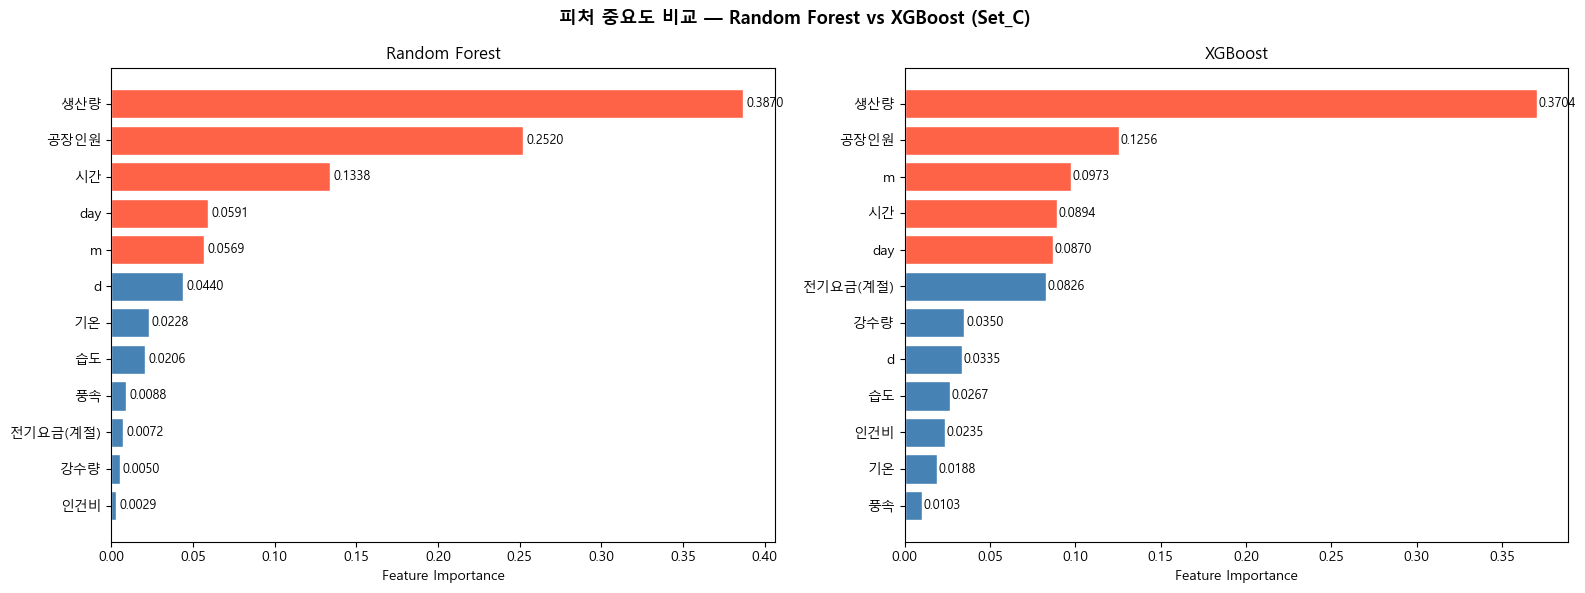


=== RF Feature Importance Top 5 ===
생산량     0.387022
공장인원    0.251998
시간      0.133800
day     0.059083
m       0.056860

=== XGBoost Feature Importance Top 5 ===
생산량     0.370351
공장인원    0.125598
m       0.097304
시간      0.089377
day     0.086957


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처 중요도 비교 — Random Forest vs XGBoost (Set_C)', fontsize=13, fontweight='bold')

feature_names = FEATURE_SETS['Set_C']

# RF Feature Importance
fi_rf = pd.Series(rf_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_rf = ['tomato' if v > fi_rf.quantile(0.6) else 'steelblue' for v in fi_rf.values]
axes[0].barh(fi_rf.index, fi_rf.values, color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest', fontsize=12)
axes[0].set_xlabel('Feature Importance')
for i, val in enumerate(fi_rf.values):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# XGBoost Feature Importance
fi_xgb = pd.Series(xgb_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_xgb = ['tomato' if v > fi_xgb.quantile(0.6) else 'steelblue' for v in fi_xgb.values]
axes[1].barh(fi_xgb.index, fi_xgb.values, color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost', fontsize=12)
axes[1].set_xlabel('Feature Importance')
for i, val in enumerate(fi_xgb.values):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RF Feature Importance Top 5 ===")
print(fi_rf.sort_values(ascending=False).head(5).to_string())
print("\n=== XGBoost Feature Importance Top 5 ===")
print(fi_xgb.sort_values(ascending=False).head(5).to_string())

# Step 24

  최종 모델 성능 비교 (Set_C 기준)
                             모델  RMSE   MAE     R²
              XGB_Tuned [Set_C] 12.84  8.00 0.9481
                XGBoost [Set_C] 13.33  8.47 0.9441
               RF_Tuned [Set_C] 14.26  8.72 0.9360
           RandomForest [Set_C] 14.26  8.47 0.9359
           DecisionTree [Set_C] 18.51 10.28 0.8922
   DNN-Medium  [128,64] [Set_C] 20.99 14.65 0.8613
DNN-Deep    [128,64,32] [Set_C] 21.59 15.26 0.8532
       DNN-Shallow [64] [Set_C] 30.98 24.02 0.6979


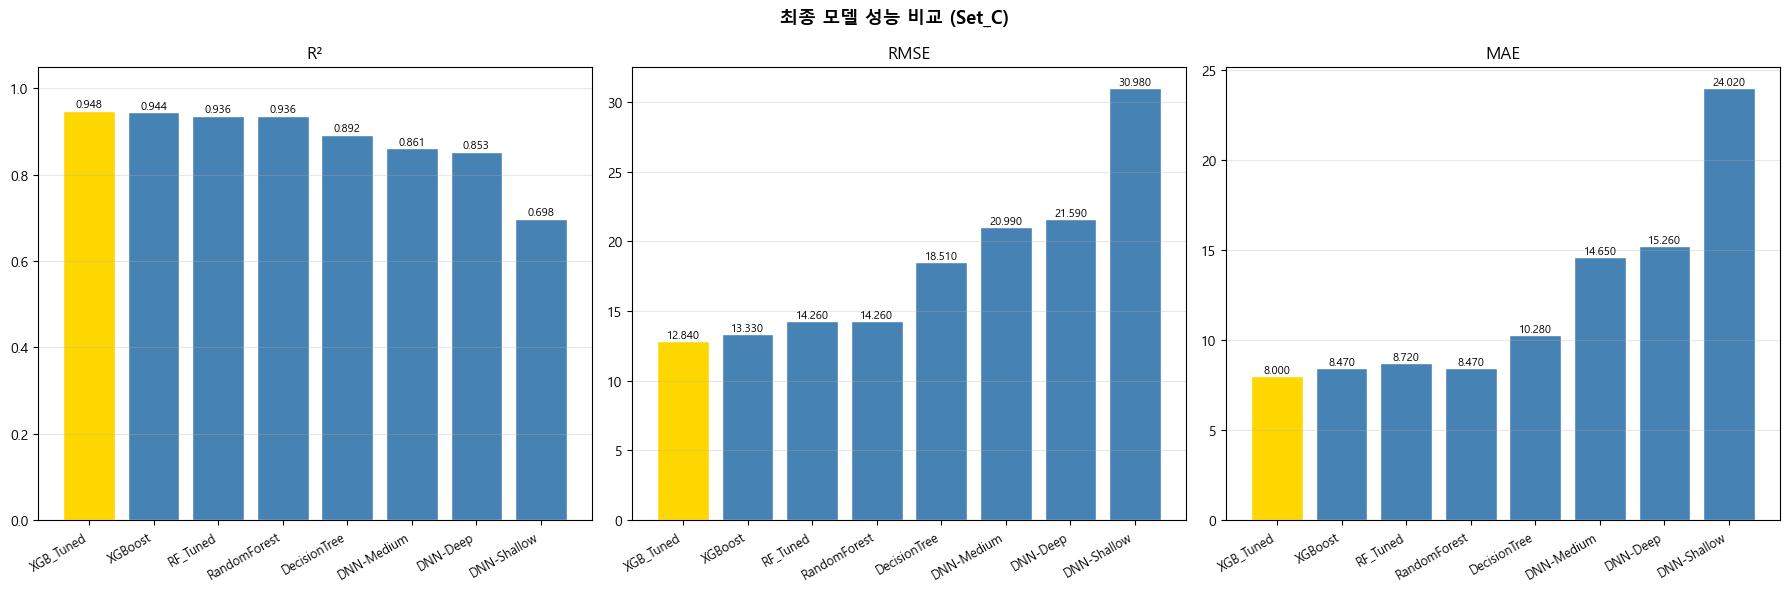

In [26]:
results_df = pd.DataFrame(all_results)

# Set_C 결과만 필터링해서 보기
setC_results = results_df[results_df['모델'].str.contains('Set_C')].sort_values('R²', ascending=False)

print("=" * 65)
print("  최종 모델 성능 비교 (Set_C 기준)")
print("=" * 65)
print(setC_results.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('최종 모델 성능 비교 (Set_C)', fontsize=13, fontweight='bold')

model_labels = [m.split('[')[0].strip() for m in setC_results['모델']]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(setC_results))]

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(model_labels, setC_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xticklabels(model_labels, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, setC_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'R²':
        ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Step 25

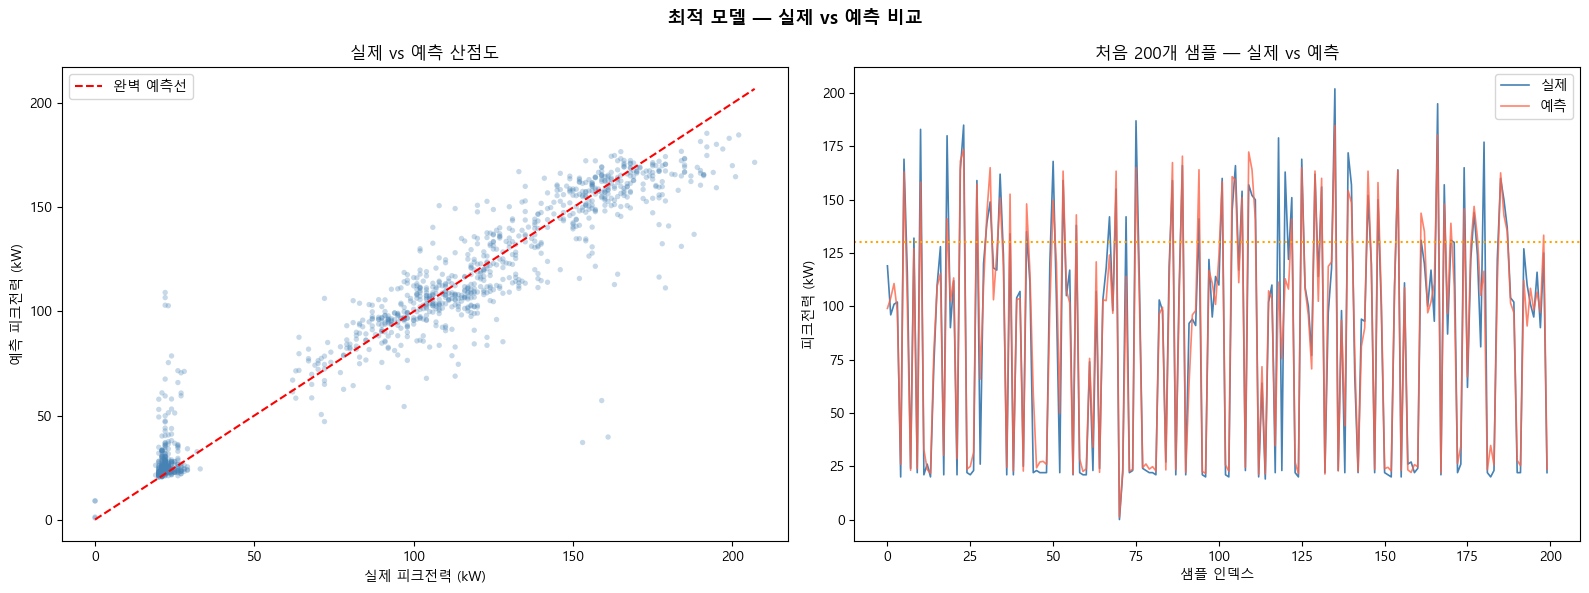


최적 모델 최종 성능
  RMSE : 14.26 kW  (평균 피크 90kW 대비 오차율 15.8%)
  R²   : 0.9360


In [27]:
# 최적 모델로 예측
best_model = rf_tuned   # RF_Tuned 또는 XGB_Tuned 중 R²가 높은 것
y_pred_best = best_model.predict(splits['Set_C']['X_test'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('최적 모델 — 실제 vs 예측 비교', fontsize=13, fontweight='bold')

# 1) 산점도
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', edgecolor='none', s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='완벽 예측선')
axes[0].set_xlabel('실제 피크전력 (kW)')
axes[0].set_ylabel('예측 피크전력 (kW)')
axes[0].set_title('실제 vs 예측 산점도')
axes[0].legend()

# 2) 처음 200개 시계열 비교
idx = range(200)
axes[1].plot(idx, list(y_test)[:200],      label='실제', color='steelblue', linewidth=1.2)
axes[1].plot(idx, y_pred_best[:200], label='예측', color='tomato',    linewidth=1.2, alpha=0.8)
axes[1].set_xlabel('샘플 인덱스')
axes[1].set_ylabel('피크전력 (kW)')
axes[1].set_title('처음 200개 샘플 — 실제 vs 예측')
axes[1].legend()
axes[1].axhline(130, color='orange', linestyle=':', linewidth=1.5, label='고피크 기준(130kW)')

plt.tight_layout()
plt.show()

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"\n최적 모델 최종 성능")
print(f"  RMSE : {rmse_final:.2f} kW  (평균 피크 90kW 대비 오차율 {rmse_final/y.mean()*100:.1f}%)")
print(f"  R²   : {r2_score(y_test, y_pred_best):.4f}")

# Step 26

In [28]:
import joblib
import os
from sklearn.pipeline import Pipeline

os.makedirs('./models', exist_ok=True)

# 최적 파라미터로 파이프라인 구성
best_params = rf_tuned.best_params_

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),                        # 스케일링 (RF는 불필요하지만 통일성 유지)
    ('model' , RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Set_C 피처로 재학습
final_pipeline.fit(splits['Set_C']['X_train'], y_train)

# 저장
save_path = './models/energy_pipeline.pkl'
joblib.dump({
    'pipeline'    : final_pipeline,
    'feature_cols': FEATURE_SETS['Set_C'],
    'scaler'      : scalers['Set_C'],
    'best_params' : best_params,
}, save_path)

size_mb = os.path.getsize(save_path) / (1024**2)
print(f"✅ 모델 저장 완료: {save_path}  ({size_mb:.2f} MB)")

# 로드 후 검증
loaded = joblib.load(save_path)
y_check = loaded['pipeline'].predict(splits['Set_C']['X_test'])
print(f"   로드 후 R² 검증: {r2_score(y_test, y_check):.4f}  ✅")

✅ 모델 저장 완료: ./models/energy_pipeline.pkl  (67.00 MB)
   로드 후 R² 검증: 0.9360  ✅


In [56]:
# 확인용 셀
import pandas as pd

asos_path = r'C:\Users\Admin\hipython\ml\data\asos_solar_2021.csv'
df_check = pd.read_csv(asos_path)
print(f"행 수: {len(df_check):,}")
print(f"날짜 범위: {df_check['날짜_key'].min()} ~ {df_check['날짜_key'].max()}")
print(f"월별 행 수:")
df_check['월'] = df_check['날짜_key'].astype(str).str[4:6].astype(int)
print(df_check.groupby('월').size().to_string())

행 수: 8,760
날짜 범위: 20210101 ~ 20211231
월별 행 수:
월
1     744
2     672
3     744
4     720
5     744
6     720
7     744
8     744
9     720
10    744
11    720
12    744


# Step 27 데이터 증강 9개월 -> 1년 

In [66]:
# ================================================
# Step 27: 방법3 — Top6 규칙 기반 1년치 증강
# 원본(1/1~9/14) 완전 보존
# 확장(9/15~12/31): ASOS 실제날씨 + Top6 규칙 생산량
# ================================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

np.random.seed(42)

# ── 로드 ──────────────────────────────────────────
for p in [r'C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv',
          r'C:\Users\Admin\hipython\data\okm_augumented_2021.csv']:
    if os.path.exists(p):
        df_okm = pd.read_csv(p)
        print(f"OKM 로드: {p}")
        break

df_okm = df_okm[df_okm['시간']<=23].copy()
df_okm['공장인원'] = df_okm['공장인원'].fillna(0)
df_okm['강수량']   = df_okm['강수량'].fillna(0)
df_okm['풍속']     = df_okm['풍속'].fillna(df_okm['풍속'].median())

asos_path = r'C:\Users\Admin\hipython\ml\data\asos_solar_2021.csv'
df_asos = pd.read_csv(asos_path)
df_asos['날짜_key'] = df_asos['날짜_key'].astype(int)
df_asos['시간_key'] = df_asos['시간_key'].astype(int)
df_asos['asos_rn']  = df_asos['asos_rn'].fillna(0)
df_asos['asos_ws']  = df_asos['asos_ws'].fillna(df_asos['asos_ws'].median())
for c in ['asos_ta','asos_hm']:
    df_asos[c] = pd.to_numeric(df_asos[c], errors='coerce').interpolate().fillna(method='bfill')

print(f"OKM: {len(df_okm):,}행 / ASOS: {len(df_asos):,}행")

# ── STEP 1: 원본 + 일사량 병합 ───────────────────
df_orig = df_okm.copy()
df_orig['날짜_key'] = df_orig['날짜'].astype(int)
df_orig['시간_key'] = df_orig['시간'].astype(int)
df_orig = df_orig.merge(
    df_asos[['날짜_key','시간_key','solar_MJ']],
    on=['날짜_key','시간_key'], how='left')
night = (df_orig['시간']<=5)|(df_orig['시간']>=19)
df_orig.loc[night & df_orig['solar_MJ'].isna(), 'solar_MJ'] = 0.0
df_orig['solar_MJ'] = df_orig['solar_MJ'].interpolate().fillna(0).clip(lower=0)
df_orig = df_orig.drop(columns=['날짜_key','시간_key'])
print(f"원본 준비: {len(df_orig):,}행")

# ── STEP 2: 9/15~12/31 날짜 프레임 생성 ──────────
rows = []
cur  = datetime(2021, 9, 15)
while cur <= datetime(2021, 12, 31, 23):
    rows.append({'날짜': int(cur.strftime('%Y%m%d')), '시간': cur.hour})
    cur += timedelta(hours=1)
df_ext = pd.DataFrame(rows)
df_ext['m']   = df_ext['날짜'].astype(str).str[4:6].astype(int)
df_ext['d']   = df_ext['날짜'].astype(str).str[6:8].astype(int)
df_ext['day'] = pd.to_datetime(
    df_ext['날짜'].astype(str), format='%Y%m%d').dt.weekday + 1
print(f"확장 기간: {len(df_ext):,}행 (9/15~12/31)")

# ── STEP 3: 실제 ASOS 날씨 병합 ──────────────────
df_ext['날짜_key'] = df_ext['날짜'].astype(int)
df_ext['시간_key'] = df_ext['시간'].astype(int)
df_ext = df_ext.merge(
    df_asos[['날짜_key','시간_key','solar_MJ',
             'asos_ta','asos_hm','asos_ws','asos_rn']],
    on=['날짜_key','시간_key'], how='left'
).rename(columns={
    'asos_ta':'기온','asos_hm':'습도',
    'asos_ws':'풍속','asos_rn':'강수량'
})
night2 = (df_ext['시간']<=5)|(df_ext['시간']>=19)
df_ext.loc[night2 & df_ext['solar_MJ'].isna(), 'solar_MJ'] = 0.0
df_ext['solar_MJ'] = df_ext['solar_MJ'].interpolate().fillna(0).clip(lower=0)
for c in ['기온','습도','풍속','강수량']:
    df_ext[c] = df_ext[c].interpolate().fillna(method='bfill').fillna(method='ffill')
df_ext = df_ext.drop(columns=['날짜_key','시간_key'])
print(f"날씨 병합 완료 | 기온: {df_ext['기온'].min():.1f}~{df_ext['기온'].max():.1f}°C")

# ── STEP 4: Top6 규칙 기반 생산량 생성 ───────────
winter = df_okm[df_okm['m'].isin([1,2])].copy()
winter['wd'] = pd.to_datetime(
    winter['날짜'].astype(str)+winter['시간'].astype(str).str.zfill(2),
    format='%Y%m%d%H').dt.weekday

prod_table   = winter.groupby(['wd','시간'])['생산량'].mean().reset_index()
worker_table = winter.groupby(['wd','시간'])['공장인원'].mean().reset_index()
prod_table.columns   = ['wd','시간','avg_prod']
worker_table.columns = ['wd','시간','avg_worker']

df_ext['wd'] = df_ext['day'] - 1
df_ext = df_ext.merge(prod_table,   on=['wd','시간'], how='left')
df_ext = df_ext.merge(worker_table, on=['wd','시간'], how='left')
df_ext['avg_prod']   = df_ext['avg_prod'].fillna(0)
df_ext['avg_worker'] = df_ext['avg_worker'].fillna(0)

# 일요일 완전 휴무
df_ext.loc[df_ext['wd']==6, ['avg_prod','avg_worker']] = 0

# 토요일 50% 특근
sat_idx = df_ext.index[df_ext['wd']==5]
sat_off = sat_idx[np.random.random(len(sat_idx)) < 0.5]
df_ext.loc[sat_off, ['avg_prod','avg_worker']] = 0

# 노이즈 추가
df_ext['생산량']   = (df_ext['avg_prod']   +
    np.random.normal(0, df_ext['avg_prod']*0.05+2, len(df_ext))
    ).clip(lower=0).round().astype(int)
df_ext['공장인원'] = (df_ext['avg_worker'] +
    np.random.normal(0, 0.3, len(df_ext))
    ).clip(lower=0).round(2)
df_ext['인건비']   = df_ext['시간'].apply(lambda h: 1.5 if 8<=h<=18 else 1.0)
df_ext = df_ext.drop(columns=['wd','avg_prod','avg_worker'])
print(f"생산량 생성 완료 | 평균: {df_ext['생산량'].mean():.0f}개")

# ── STEP 5: 전기요금 + 15분 피크 생성 ────────────
def tariff(m):
    return 109.8 if m in [1,2,11,12] else (191.6 if m in [6,7,8] else 167.2)
df_ext['전기요금(계절)'] = df_ext['m'].apply(tariff)

def peak(prod, worker, h):
    if prod > 0:
        return max(0, 25 + min(prod/500*60, 120) + worker*3 + np.random.normal(0,8))
    if 8<=h<=18 and np.random.random()<0.15:
        return max(0, np.random.normal(75, 20))
    return max(0, np.random.normal(25, 5))

df_ext['15분'] = df_ext.apply(
    lambda r: round(peak(r['생산량'], r['공장인원'], r['시간']), 1), axis=1)
df_ext['30분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['45분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['60분'] = (df_ext['15분']*np.random.uniform(0.95,1.05,len(df_ext))).round(1)
df_ext['평균']  = ((df_ext['15분']+df_ext['30분']+
                   df_ext['45분']+df_ext['60분'])/4).round(1)

# ── STEP 6: 합치기 + 저장 ────────────────────────
okm_cols = list(df_okm.columns) + ['solar_MJ']
df_work  = pd.concat([df_orig[okm_cols], df_ext[okm_cols]], ignore_index=True)
df_work  = df_work.sort_values(['날짜','시간']).reset_index(drop=True)

os.makedirs('./data', exist_ok=True)
df_work.to_csv('./data/okm_full_2021.csv', index=False, encoding='utf-8-sig')

print(f"\n=== 최종 요약 ===")
print(f"전체 행 수: {len(df_work):,}")
print(f"날짜 범위 : {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"컬럼 수   : {df_work.shape[1]}")
print(f"\n월별 생산량 평균:")
print(df_work.groupby('m')['생산량'].mean().round(0).to_string())
print(f"\n월별 평균 기온:")
print(df_work.groupby('m')['기온'].mean().round(1).to_string())
print(f"\n저장 완료: ./data/okm_full_2021.csv")
print("Step 27 완료")

OKM 로드: C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv
OKM: 6,120행 / ASOS: 8,760행
원본 준비: 6,120행
확장 기간: 2,592행 (9/15~12/31)
날씨 병합 완료 | 기온: -15.4~29.3°C
생산량 생성 완료 | 평균: 370개

=== 최종 요약 ===
전체 행 수: 8,712
날짜 범위 : 20210101 ~ 20211231
컬럼 수   : 19

월별 생산량 평균:
m
1     261.0
2     473.0
3     410.0
4     518.0
5     500.0
6     557.0
7     567.0
8     463.0
9     451.0
10    351.0
11    378.0
12    377.0

월별 평균 기온:
m
1      2.0
2      6.5
3     10.5
4     13.8
5     17.7
6     21.6
7     25.9
8     25.3
9     22.3
10    15.6
11     8.2
12     0.6

저장 완료: ./data/okm_full_2021.csv
Step 27 완료


# 확인용

In [68]:
print(f"행 수    : {len(df_work):,}")
print(f"날짜 범위: {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"월별 행수:")
print(df_work['m'].value_counts().sort_index())

행 수    : 8,712
날짜 범위: 20210101 ~ 20211231
월별 행수:
m
1     744
2     672
3     744
4     720
5     744
6     720
7     696
8     744
9     720
10    744
11    720
12    744
Name: count, dtype: int64


# Step 28 기상청 ASOS 일사량 수집 및 병합

In [ ]:
# ================================================
# Step 28: 기상청 ASOS 일사량 + 날씨 수집 (1~12월)
# ================================================

import requests, time, os, pandas as pd
from datetime import datetime, timedelta

API_KEY   = ""
STN_ID    = "108"
URL       = "http://apis.data.go.kr/1360000/AsosHourlyInfoService/getWthrDataList"
SAVE_PATH = r'C:\Users\Admin\hipython\ml\data\asos_solar_2021.csv'

def fetch_chunk(s, e):
    days = (datetime.strptime(e,"%Y%m%d") -
            datetime.strptime(s,"%Y%m%d")).days + 1
    params = {
        "serviceKey": API_KEY, "numOfRows": str(days*24),
        "pageNo":"1", "dataType":"JSON", "dataCd":"ASOS",
        "dateCd":"HR", "startDt":s, "startHh":"00",
        "endDt":e, "endHh":"23", "stnIds":STN_ID,
    }
    try:
        res  = requests.get(URL, params=params, timeout=60)
        data = res.json()
        if data['response']['header']['resultCode'] != "00":
            print(f"  API 오류: {data['response']['header']['resultMsg']}")
            return []
        return data['response']['body']['items']['item']
    except Exception as ex:
        print(f"  요청 실패: {ex}")
        return []

def make_chunks(start, end, days=30):
    chunks, cur = [], datetime.strptime(start, "%Y%m%d")
    end_dt = datetime.strptime(end, "%Y%m%d")
    while cur <= end_dt:
        chunk_end = min(cur + timedelta(days=days-1), end_dt)
        chunks.append((cur.strftime("%Y%m%d"), chunk_end.strftime("%Y%m%d")))
        cur = chunk_end + timedelta(days=1)
    return chunks

# ── 이미 파일 있으면 스킵 ─────────────────────────
if os.path.exists(SAVE_PATH):
    df_check = pd.read_csv(SAVE_PATH)
    max_date = df_check['날짜_key'].max()
    if max_date >= 20211231:
        print(f"이미 1~12월 수집 완료 파일 있음 ({len(df_check):,}행)")
        print(f"날짜 범위: {df_check['날짜_key'].min()} ~ {max_date}")
        print("Step 28 스킵 -- 기존 파일 사용")
    else:
        print(f"기존 파일: {max_date}까지만 있음 → 재수집 필요")
else:
    # ── 수집 ──────────────────────────────────────
    chunks, all_records = make_chunks("20210101","20211231"), []
    print(f"수집 시작: 1~12월 | 총 {len(chunks)}구간\n")

    for i, (s, e) in enumerate(chunks, 1):
        print(f"[{i}/{len(chunks)}] {s}~{e} ...", end=" ")
        recs = fetch_chunk(s, e)
        if recs:
            all_records.extend(recs)
            print(f"{len(recs)}건")
        else:
            print("없음")
        time.sleep(1)

    print(f"\n총 수집: {len(all_records)}건")

    # ── 변환 ──────────────────────────────────────
    df_solar = pd.DataFrame(all_records)
    use_cols = [c for c in ['tm','icsr','ta','hm','ws','rn']
                if c in df_solar.columns]
    df_solar = df_solar[use_cols].rename(columns={
        'tm':'obs_time','icsr':'solar_MJ',
        'ta':'asos_ta','hm':'asos_hm','ws':'asos_ws','rn':'asos_rn'})

    df_solar['obs_time'] = pd.to_datetime(df_solar['obs_time'],
                            format='%Y-%m-%d %H:%M', errors='coerce')
    for c in ['solar_MJ','asos_ta','asos_hm','asos_ws','asos_rn']:
        df_solar[c] = pd.to_numeric(df_solar[c], errors='coerce')

    df_solar['날짜_key'] = df_solar['obs_time'].dt.strftime('%Y%m%d').astype(int)
    df_solar['시간_key'] = df_solar['obs_time'].dt.hour

    night = (df_solar['시간_key']<=5)|(df_solar['시간_key']>=19)
    df_solar.loc[night & df_solar['solar_MJ'].isna(), 'solar_MJ'] = 0.0
    df_solar['solar_MJ'] = df_solar['solar_MJ'].interpolate().fillna(0).clip(lower=0)
    df_solar['asos_rn']  = df_solar['asos_rn'].fillna(0)
    for c in ['asos_ta','asos_hm','asos_ws']:
        df_solar[c] = df_solar[c].interpolate().fillna(method='bfill').fillna(method='ffill')

    df_solar.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
    print(f"\n저장 완료: {SAVE_PATH}")
    print(f"행 수    : {len(df_solar):,}")
    print(f"날짜 범위: {df_solar['날짜_key'].min()} ~ {df_solar['날짜_key'].max()}")
    df_solar['월'] = df_solar['obs_time'].dt.month
    print(df_solar.groupby('월').size().to_string())
    print("Step 28 완료")

이미 1~12월 수집 완료 파일 있음 (8,760행)
날짜 범위: 20210101 ~ 20211231
Step 28 스킵 -- 기존 파일 사용


# Step 29 공휴일·요일 파생변수 생성

In [90]:
# ================================================
# Step 29: 공휴일·요일 파생변수 생성
# df_work 기준 (1년치 8,712행)
# ================================================

# df_work 기준으로 명시적 시작
df_merged = df_work.copy()
print(f"시작: {len(df_merged):,}행 | {df_merged['날짜'].min()}~{df_merged['날짜'].max()}")

holidays_2021 = [
    20210101,20210212,20210301,20210505,20210519,
    20210606,20210815,20210920,20210921,20210922,20211003
]

df_merged['datetime'] = pd.to_datetime(
    df_merged['날짜'].astype(str) +
    df_merged['시간'].astype(str).str.zfill(2), format='%Y%m%d%H')
df_merged['weekday']    = df_merged['datetime'].dt.weekday
df_merged['is_weekend'] = (df_merged['weekday'] >= 5).astype(int)
df_merged['is_holiday'] = df_merged['날짜'].astype(int).isin(holidays_2021).astype(int)
df_merged['주간여부']    = ((df_merged['시간'] >= 8) & (df_merged['시간'] <= 18)).astype(int)
df_merged['가동여부']    = (df_merged['생산량'] > 0).astype(int)
df_merged = df_merged.drop(columns=['datetime'])

print(f"행 수      : {len(df_merged):,}")
print(f"날짜 범위  : {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")
print(f"is_weekend : 주말 {df_merged['is_weekend'].sum():,}건 / 평일 {(df_merged['is_weekend']==0).sum():,}건")
print(f"is_holiday : 공휴일 {df_merged['is_holiday'].sum():,}건")
print(f"가동여부   : 가동 {df_merged['가동여부'].sum():,}건 / 비가동 {(df_merged['가동여부']==0).sum():,}건")
print("Step 29 완료")

시작: 8,712행 | 20210101~20211231
행 수      : 8,712
날짜 범위  : 20210101 ~ 20211231
is_weekend : 주말 2,496건 / 평일 6,216건
is_holiday : 공휴일 264건
가동여부   : 가동 5,641건 / 비가동 3,071건
Step 29 완료


Step 29-1 : 열처리로 가동여부 역추론

In [91]:
# ================================================
# Step 29-1: 열처리로 가동여부 역추론
# ================================================

import pandas as pd
import numpy as np
import os

# ── df_merged 없으면 CSV에서 로드 ─────────────────
if 'df_merged' not in dir():
    csv_path = './data/okm_enriched_final.csv'
    if os.path.exists(csv_path):
        df_merged = pd.read_csv(csv_path)
        print(f"CSV 로드 완료: {len(df_merged):,}행")
    else:
        print("okm_enriched_final.csv 파일이 없습니다.")
        print("Step 33까지 먼저 실행해주세요.")
        raise FileNotFoundError("okm_enriched_final.csv 없음")
else:
    print(f"df_merged 이미 존재: {len(df_merged):,}행")

# ── 열처리로 역추론 함수 ──────────────────────────
def infer_furnace(row):
    prod = row['생산량']
    peak = row['15분']
    if prod > 0:
        return 1      # 생산 중 → 열처리로 ON 확실
    elif peak >= 60:
        return 1      # 비가동이지만 고전력 → 예열/냉각 중
    elif peak < 30:
        return 0      # 완전 휴지 → OFF
    else:
        return -1     # 불확실 구간 (30~60kW)

df_merged['furnace_raw'] = df_merged.apply(infer_furnace, axis=1)

# 불확실 구간(-1) → 직전 상태로 채우기
df_merged['furnace_on'] = df_merged['furnace_raw'].replace(-1, np.nan)
df_merged['furnace_on'] = (
    df_merged['furnace_on']
    .fillna(method='ffill')
    .fillna(0)
    .astype(int)
)

# furnace_raw 제거
df_merged = df_merged.drop(columns=['furnace_raw'])

# ── 결과 확인 ─────────────────────────────────────
total   = len(df_merged)
on_cnt  = df_merged['furnace_on'].sum()
off_cnt = total - on_cnt

print(f"\n=== 열처리로 가동여부 추정 결과 ===")
print(f"ON  (가동 추정): {on_cnt:,}건 ({on_cnt/total*100:.1f}%)")
print(f"OFF (휴지 추정): {off_cnt:,}건 ({off_cnt/total*100:.1f}%)")

print(f"\n=== 구간별 평균 전력 검증 ===")
chk = df_merged.groupby('furnace_on')['15분'].agg(['mean','min','max']).round(1)
chk.index = ['OFF','ON']
print(chk.to_string())

print(f"\n비가동(생산=0) 중 열처리로 ON 비율:")
non_prod = df_merged[df_merged['생산량']==0]
furnace_during_rest = non_prod['furnace_on'].mean() * 100
print(f"  {furnace_during_rest:.1f}% -- 쉬는 시간에도 열처리로 가동 중")

# ── CSV 저장 (furnace_on 추가된 버전으로 덮어쓰기) ─
df_merged.to_csv('./data/okm_enriched_final.csv',
                 index=False, encoding='utf-8-sig')
print(f"\n저장 완료: ./data/okm_enriched_final.csv")
print(f"컬럼 수: {df_merged.shape[1]}")
print("Step 29-1 완료 -- furnace_on 컬럼 추가됨")

df_merged 이미 존재: 8,712행

=== 열처리로 가동여부 추정 결과 ===
ON  (가동 추정): 6,342건 (72.8%)
OFF (휴지 추정): 2,370건 (27.2%)

=== 구간별 평균 전력 검증 ===
      mean  min    max
OFF   22.5  0.0   55.6
ON   105.4  0.0  207.0

비가동(생산=0) 중 열처리로 ON 비율:
  22.8% -- 쉬는 시간에도 열처리로 가동 중

저장 완료: ./data/okm_enriched_final.csv
컬럼 수: 25
Step 29-1 완료 -- furnace_on 컬럼 추가됨


# Step 30 한전 TOU 요금 구간 생성 

In [92]:
# ================================================
# Step 30: 한전 TOU 요금 구간 생성
# 경부하=0 / 중간부하=1 / 최대부하=2
# ================================================

def get_tou_bucket(month, hour):
    if hour >= 22 or hour <= 7:
        return 0
    if month in [6,7,8]:
        if hour in [11,12,13,14,15,16,17]: return 2
        else: return 1
    elif month in [11,12,1,2]:
        if hour in [10,17,18,19,20]: return 2
        else: return 1
    else:
        return 1

df_merged['tou_bucket'] = df_merged.apply(
    lambda r: get_tou_bucket(int(r['m']), int(r['시간'])), axis=1)

tou_price_map = {0: 95.7, 1: 121.5, 2: 155.0}
df_merged['tou_price'] = df_merged['tou_bucket'].map(tou_price_map)

print(f"행 수      : {len(df_merged):,}")
print(f"날짜 범위  : {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")
print(f"경부하(0)  : {(df_merged['tou_bucket']==0).sum():,}건  95.7원/kWh")
print(f"중간부하(1): {(df_merged['tou_bucket']==1).sum():,}건  121.5원/kWh")
print(f"최대부하(2): {(df_merged['tou_bucket']==2).sum():,}건  155.0원/kWh")
print("Step 30 완료")

행 수      : 8,712
날짜 범위  : 20210101 ~ 20211231
경부하(0)  : 3,630건  95.7원/kWh
중간부하(1): 3,852건  121.5원/kWh
최대부하(2): 1,230건  155.0원/kWh
Step 30 완료


# Step 31: SMP(계통한계가격) 데이터 병합

In [93]:
# ================================================
# Step 31: SMP(계통한계가격) 데이터 병합
# ================================================

smp_path = r'C:\Users\Admin\hipython\ml\data\HOME_전력거래_계통한계가격_시간별SMP.csv'
df_smp_raw = pd.read_csv(smp_path, encoding='cp949')

df_smp = df_smp_raw.rename(columns={
    '기간'       : 'ym',
    'SMP'        : 'smp_land',
    'Unnamed: 2' : 'smp_jeju',
    'Unnamed: 3' : 'smp_total',
})
df_smp = df_smp[df_smp['ym'] != '육지']
df_smp = df_smp.dropna(subset=['ym']).reset_index(drop=True)
df_smp['smp_land']  = pd.to_numeric(df_smp['smp_land'],  errors='coerce')
df_smp['smp_total'] = pd.to_numeric(df_smp['smp_total'], errors='coerce')
df_smp['year'] = df_smp['ym'].str.split('/').str[0].astype(int)
df_smp['m']    = df_smp['ym'].str.split('/').str[1].astype(int)

df_smp_2021 = df_smp[
    df_smp['year']==2021
][['m','smp_land','smp_total']].copy().reset_index(drop=True)

print(f"2021년 SMP: {len(df_smp_2021)}개월")
print(df_smp_2021.sort_values('m').to_string(index=False))

df_merged = df_merged.merge(df_smp_2021, on='m', how='left')

print(f"\n행 수      : {len(df_merged):,}")
print(f"날짜 범위  : {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")
print(f"smp_land 결측: {df_merged['smp_land'].isna().sum()}개")
print(f"smp_land 평균: {df_merged['smp_land'].mean():.2f} 원/kWh")
print("Step 31 완료")

2021년 SMP: 12개월
 m  smp_land  smp_total
 1     70.47      70.65
 2     75.25      75.44
 3     83.78      84.22
 4     75.97      76.35
 5     78.93      79.10
 6     82.72      83.11
 7     87.04      87.54
 8     93.41      94.07
 9     98.21      98.77
10    107.53     107.76
11    126.83     127.06
12    142.46     142.81

행 수      : 8,712
날짜 범위  : 20210101 ~ 20211231
smp_land 결측: 0개
smp_land 평균: 93.71 원/kWh
Step 31 완료


# Step 32: 국가 전력 탄소 배출 계수 추가

In [94]:
# ================================================
# Step 32: 국가 전력 탄소 배출 계수 추가
# 0.4153 tCO2eq/MWh (2021년 기준)
# ================================================

EMISSION_FACTOR = 0.4153

df_merged['co2_kg'] = (df_merged['15분'] / 1000 * EMISSION_FACTOR * 1000).round(4)

monthly_co2 = df_merged.groupby('m').agg(
    월전력kWh=('15분','sum'),
    월탄소배출tCO2=('co2_kg', lambda x: round(x.sum()/1000, 2))
).reset_index()

print(f"배출계수   : {EMISSION_FACTOR} tCO2eq/MWh")
print(f"co2_kg 평균: {df_merged['co2_kg'].mean():.4f} kg/시간")
print(f"co2_kg 최대: {df_merged['co2_kg'].max():.4f} kg/시간")
print(f"\n=== 월별 탄소 배출량 ===")
print(monthly_co2.to_string(index=False))
print(f"\n총 탄소 배출: {monthly_co2['월탄소배출tCO2'].sum():.2f} tCO2eq")
print(f"\n행 수      : {len(df_merged):,}")
print(f"날짜 범위  : {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")
print("Step 32 완료")

배출계수   : 0.4153 tCO2eq/MWh
co2_kg 평균: 34.3975 kg/시간
co2_kg 최대: 85.9671 kg/시간

=== 월별 탄소 배출량 ===
 m  월전력kWh  월탄소배출tCO2
 1 60169.0      24.99
 2 59865.0      24.86
 3 72004.0      29.90
 4 65577.0      27.23
 5 61800.0      25.67
 6 71736.0      29.79
 7 68226.0      28.33
 8 58621.0      24.35
 9 58837.2      24.44
10 47452.8      19.71
11 47600.3      19.77
12 49688.0      20.64

총 탄소 배출: 299.68 tCO2eq

행 수      : 8,712
날짜 범위  : 20210101 ~ 20211231
Step 32 완료


# Stpe 33 최종 데이터 저장

In [96]:
# ================================================
# Step 33: 최종 데이터 저장
# ================================================

import os
os.makedirs('./data', exist_ok=True)

missing = df_merged.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("결측치 없음")
else:
    print("결측치 있는 컬럼:")
    print(missing.to_string())

save_csv = './data/okm_enriched_final.csv'
df_merged.to_csv(save_csv, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(save_csv) / 1024

print(f"\n=== 최종 데이터 요약 ===")
print(f"행 수      : {len(df_merged):,}")
print(f"컬럼 수    : {df_merged.shape[1]}")
print(f"날짜 범위  : {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")
print(f"파일 크기  : {size_kb:.1f} KB")
print(f"저장 경로  : {save_csv}")
print(f"\n=== 추가 피처 확인 ===")
print(f"solar_MJ 평균 : {df_merged['solar_MJ'].mean():.3f} MJ/m2")
print(f"is_holiday    : {df_merged['is_holiday'].sum():,}건")
print(f"is_weekend    : {df_merged['is_weekend'].sum():,}건")
print(f"furnace_on    : {df_merged['furnace_on'].sum():,}건")
print(f"tou_bucket 0  : {(df_merged['tou_bucket']==0).sum():,}건")
print(f"tou_bucket 1  : {(df_merged['tou_bucket']==1).sum():,}건")
print(f"tou_bucket 2  : {(df_merged['tou_bucket']==2).sum():,}건")
print(f"smp_land 평균 : {df_merged['smp_land'].mean():.2f} 원/kWh")
print(f"co2_kg 평균   : {df_merged['co2_kg'].mean():.4f} kg/h")
print(f"\n=== 전체 컬럼 목록 ===")
for i, col in enumerate(df_merged.columns, 1):
    print(f"  {i:2d}. {col}")
print("\nStep 33 완료")

결측치 없음

=== 최종 데이터 요약 ===
행 수      : 8,712
컬럼 수    : 30
날짜 범위  : 20210101 ~ 20211231
파일 크기  : 1085.0 KB
저장 경로  : ./data/okm_enriched_final.csv

=== 추가 피처 확인 ===
solar_MJ 평균 : 0.589 MJ/m2
is_holiday    : 264건
is_weekend    : 2,496건
furnace_on    : 6,342건
tou_bucket 0  : 3,630건
tou_bucket 1  : 3,852건
tou_bucket 2  : 1,230건
smp_land 평균 : 93.71 원/kWh
co2_kg 평균   : 34.3975 kg/h

=== 전체 컬럼 목록 ===
   1. 날짜
   2. 시간
   3. 15분
   4. 30분
   5. 45분
   6. 60분
   7. 평균
   8. 생산량
   9. 기온
  10. 풍속
  11. 습도
  12. 강수량
  13. 전기요금(계절)
  14. day
  15. d
  16. m
  17. 공장인원
  18. 인건비
  19. solar_MJ
  20. weekday
  21. is_weekend
  22. is_holiday
  23. 주간여부
  24. 가동여부
  25. furnace_on
  26. tou_bucket
  27. tou_price
  28. smp_land
  29. smp_total
  30. co2_kg

Step 33 완료


# 최종 데이터 확인

In [97]:
print(f"행 수    : {len(df_merged):,}")
print(f"날짜 범위: {df_merged['날짜'].min()} ~ {df_merged['날짜'].max()}")

행 수    : 8,712
날짜 범위: 20210101 ~ 20211231


# Step 34 새 Feature Set 정의 

In [98]:
# ================================================
# Step 34: 새 Feature Set 정의 + Train/Test Split
# ================================================

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = '15분'

def safe_cols(cols):
    missing = [c for c in cols if c not in df_merged.columns]
    if missing:
        print(f"  없는 컬럼 제외: {missing}")
    return [c for c in cols if c in df_merged.columns]

FEATURE_SETS_NEW = {
    'Set_A': safe_cols([
        '시간','생산량','가동여부','공장인원',
        'day','d','m','weekday','is_weekend','is_holiday',
        '주간여부','furnace_on'
    ]),
    'Set_B': safe_cols([
        '시간','생산량','가동여부','공장인원',
        'day','d','m','weekday','is_weekend','is_holiday',
        '주간여부','furnace_on',
        '기온','습도','풍속','강수량','solar_MJ'
    ]),
    'Set_C': safe_cols([
        '시간','생산량','가동여부','공장인원',
        'day','d','m','weekday','is_weekend','is_holiday',
        '주간여부','furnace_on',
        '기온','습도','풍속','강수량','solar_MJ',
        '전기요금(계절)','tou_bucket','tou_price',
        'smp_land','인건비','co2_kg'
    ]),
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS_NEW.items():
    print(f"  {name} ({len(cols)}개): {cols}")

X_all = df_merged[FEATURE_SETS_NEW['Set_C']]
y     = df_merged[TARGET]

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

splits_new = {}
for name, cols in FEATURE_SETS_NEW.items():
    splits_new[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

scalers_new = {}
for name, cols in FEATURE_SETS_NEW.items():
    sc = StandardScaler()
    splits_new[name]['X_train_sc'] = sc.fit_transform(splits_new[name]['X_train'])
    splits_new[name]['X_test_sc']  = sc.transform(splits_new[name]['X_test'])
    scalers_new[name] = sc

all_results_new = []

print(f"\n학습 데이터  : {X_train_all.shape[0]:,}행")
print(f"테스트 데이터: {X_test_all.shape[0]:,}행")
print("Step 34 완료")

=== Feature Set 구성 ===
  Set_A (12개): ['시간', '생산량', '가동여부', '공장인원', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', 'furnace_on']
  Set_B (17개): ['시간', '생산량', '가동여부', '공장인원', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', 'furnace_on', '기온', '습도', '풍속', '강수량', 'solar_MJ']
  Set_C (23개): ['시간', '생산량', '가동여부', '공장인원', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', 'furnace_on', '기온', '습도', '풍속', '강수량', 'solar_MJ', '전기요금(계절)', 'tou_bucket', 'tou_price', 'smp_land', '인건비', 'co2_kg']

학습 데이터  : 6,969행
테스트 데이터: 1,743행
Step 34 완료


# Step 35 Linear Regression & Ridge

In [99]:
# ================================================
# Step 35: Linear Regression & Ridge
# ================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'모델': model_name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R²': round(r2,4)}

print("=" * 55)
print("  [모델 1/2] Linear Regression & Ridge")
print("=" * 55)

for fs_name in FEATURE_SETS_NEW:
    Xtr = splits_new[fs_name]['X_train_sc']
    Xte = splits_new[fs_name]['X_test_sc']

    lr = LinearRegression()
    lr.fit(Xtr, y_train)
    res = evaluate_model(f'LinearReg [{fs_name}]', y_test, lr.predict(Xte))
    all_results_new.append(res)
    print(f"  LinearReg {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

    ridge = Ridge(alpha=1.0)
    ridge.fit(Xtr, y_train)
    res = evaluate_model(f'Ridge [{fs_name}]', y_test, ridge.predict(Xte))
    all_results_new.append(res)
    print(f"  Ridge     {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

print("Step 35 완료")

  [모델 1/2] Linear Regression & Ridge
  LinearReg Set_A  | RMSE= 29.43 | MAE= 22.97 | R²=0.7109
  Ridge     Set_A  | RMSE= 29.43 | MAE= 22.97 | R²=0.7109
  LinearReg Set_B  | RMSE= 29.05 | MAE= 22.23 | R²=0.7183
  Ridge     Set_B  | RMSE= 29.05 | MAE= 22.23 | R²=0.7183
  LinearReg Set_C  | RMSE=  0.00 | MAE=  0.00 | R²=1.0000
  Ridge     Set_C  | RMSE=  0.02 | MAE=  0.01 | R²=1.0000
Step 35 완료


# Step 36 Decision Tree Regressor

In [101]:
# ================================================
# Step 36: Decision Tree Regressor
# ================================================

from sklearn.tree import DecisionTreeRegressor

print("=" * 55)
print("  [모델 3] Decision Tree Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS_NEW:
    Xtr = splits_new[fs_name]['X_train']
    Xte = splits_new[fs_name]['X_test']

    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    dt.fit(Xtr, y_train)
    res = evaluate_model(f'DecisionTree [{fs_name}]', y_test, dt.predict(Xte))
    all_results_new.append(res)
    print(f"  DecisionTree {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

print("Step 36 완료")

  [모델 3] Decision Tree Regressor
  DecisionTree Set_A  | RMSE= 12.72 | MAE=  7.92 | R²=0.9460
  DecisionTree Set_B  | RMSE= 13.19 | MAE=  8.33 | R²=0.9420
  DecisionTree Set_C  | RMSE=  0.22 | MAE=  0.06 | R²=1.0000
Step 36 완료


# Step 37 Random Forest Regressor

In [102]:
# ================================================
# Step 37: Random Forest Regressor
# ================================================

from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  [모델 4] Random Forest Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS_NEW:
    Xtr = splits_new[fs_name]['X_train']
    Xte = splits_new[fs_name]['X_test']

    rf = RandomForestRegressor(
        n_estimators=200, max_depth=15,
        min_samples_leaf=3, random_state=42, n_jobs=1
    )
    rf.fit(Xtr, y_train)
    res = evaluate_model(f'RandomForest [{fs_name}]', y_test, rf.predict(Xte))
    all_results_new.append(res)
    print(f"  RandomForest {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장 (Feature Importance용)
rf_setC_new = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_leaf=3, random_state=42, n_jobs=1
)
rf_setC_new.fit(splits_new['Set_C']['X_train'], y_train)

print("Step 37 완료")

  [모델 4] Random Forest Regressor
  RandomForest Set_A  | RMSE= 10.29 | MAE=  6.56 | R²=0.9647
  RandomForest Set_B  | RMSE= 11.34 | MAE=  7.26 | R²=0.9571
  RandomForest Set_C  | RMSE=  0.17 | MAE=  0.03 | R²=1.0000
Step 37 완료


# Step 38 : XGBoost Regressor

In [103]:
# ================================================
# Step 38: XGBoost Regressor
# ================================================

from xgboost import XGBRegressor

print("=" * 55)
print("  [모델 5] XGBoost Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS_NEW:
    Xtr = splits_new[fs_name]['X_train']
    Xte = splits_new[fs_name]['X_test']

    xgb = XGBRegressor(
        n_estimators=200, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        verbosity=0, n_jobs=1
    )
    xgb.fit(Xtr, y_train, eval_set=[(Xte, y_test)], verbose=False)
    res = evaluate_model(f'XGBoost [{fs_name}]', y_test, xgb.predict(Xte))
    all_results_new.append(res)
    print(f"  XGBoost {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장
xgb_setC_new = XGBRegressor(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbosity=0, n_jobs=1
)
xgb_setC_new.fit(splits_new['Set_C']['X_train'], y_train, verbose=False)

print("Step 38 완료")

  [모델 5] XGBoost Regressor
  XGBoost Set_A  | RMSE=  9.45 | MAE=  6.51 | R²=0.9702
  XGBoost Set_B  | RMSE= 10.20 | MAE=  6.94 | R²=0.9653
  XGBoost Set_C  | RMSE=  0.91 | MAE=  0.41 | R²=0.9997
Step 38 완료


# Step 39 : DNN (sklearn MLPRegressor)

In [104]:
# ================================================
# Step 39: DNN (sklearn MLPRegressor)
# ================================================

from sklearn.neural_network import MLPRegressor

print("=" * 55)
print("  [모델 6] DNN (sklearn MLPRegressor)")
print("  Set_C 기준으로만 실행")
print("=" * 55)

dnn_configs = {
    'DNN-Shallow [64]'       : (64,),
    'DNN-Medium  [128,64]'   : (128, 64),
    'DNN-Deep    [128,64,32]': (128, 64, 32),
}

Xtr_sc = splits_new['Set_C']['X_train_sc']
Xte_sc = splits_new['Set_C']['X_test_sc']

for dnn_name, layers in dnn_configs.items():
    dnn = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu', solver='adam',
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, random_state=42
    )
    dnn.fit(Xtr_sc, y_train)
    res = evaluate_model(f'{dnn_name} [Set_C]', y_test, dnn.predict(Xte_sc))
    all_results_new.append(res)
    print(f"  {dnn_name:28s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")
    print(f"  {'':28s}   학습 에포크: {dnn.n_iter_}회")

print("Step 39 완료")

  [모델 6] DNN (sklearn MLPRegressor)
  Set_C 기준으로만 실행
  DNN-Shallow [64]             | RMSE=  3.53 | MAE=  2.58 | R²=0.9959
                                 학습 에포크: 128회
  DNN-Medium  [128,64]         | RMSE=  2.04 | MAE=  1.37 | R²=0.9986
                                 학습 에포크: 47회
  DNN-Deep    [128,64,32]      | RMSE=  1.71 | MAE=  1.23 | R²=0.9990
                                 학습 에포크: 44회
Step 39 완료


# Step 40 : 전체 모델 성능 비교표

  전체 모델 성능 비교표 (R² 내림차순)
                             모델  RMSE   MAE     R²
              LinearReg [Set_C]  0.00  0.00 1.0000
                  Ridge [Set_C]  0.02  0.01 1.0000
           DecisionTree [Set_C]  0.22  0.06 1.0000
           DecisionTree [Set_C]  0.22  0.06 1.0000
           RandomForest [Set_C]  0.17  0.03 1.0000
                XGBoost [Set_C]  0.91  0.41 0.9997
DNN-Deep    [128,64,32] [Set_C]  1.71  1.23 0.9990
   DNN-Medium  [128,64] [Set_C]  2.04  1.37 0.9986
       DNN-Shallow [64] [Set_C]  3.53  2.58 0.9959
                XGBoost [Set_A]  9.45  6.51 0.9702
                XGBoost [Set_B] 10.20  6.94 0.9653
           RandomForest [Set_A] 10.29  6.56 0.9647
           RandomForest [Set_B] 11.34  7.26 0.9571
           DecisionTree [Set_A] 12.72  7.92 0.9460
           DecisionTree [Set_A] 12.72  7.92 0.9460
           DecisionTree [Set_B] 13.19  8.33 0.9420
           DecisionTree [Set_B] 13.19  8.33 0.9420
                  Ridge [Set_B] 29.05 22.23 0.7183
      

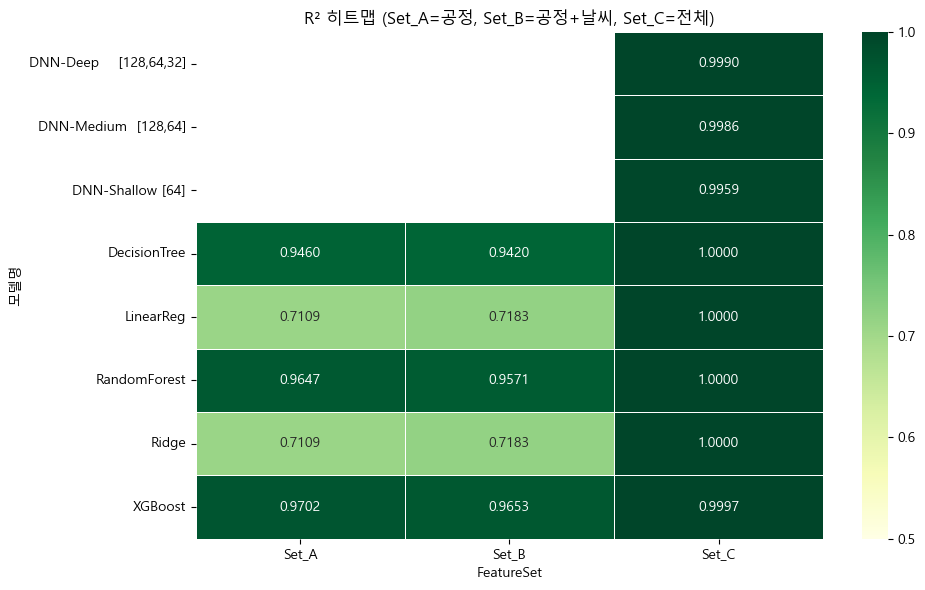

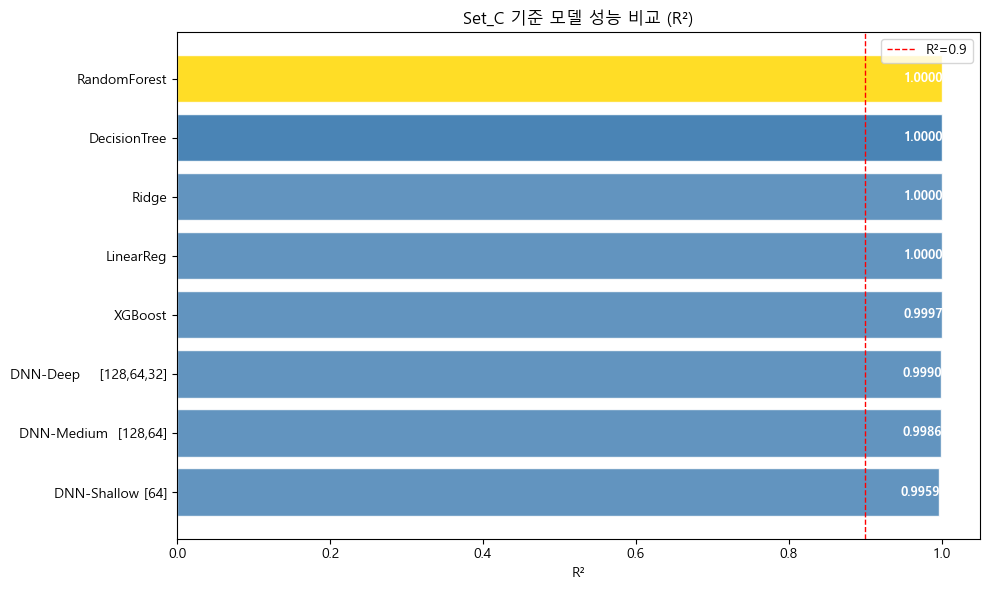

Step 40 완료


In [105]:
# ================================================
# Step 40: 전체 모델 성능 비교표
# ================================================

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

results_df_new = pd.DataFrame(all_results_new)

# 전체 비교표
print("=" * 70)
print("  전체 모델 성능 비교표 (R² 내림차순)")
print("=" * 70)
print(results_df_new.sort_values('R²', ascending=False).to_string(index=False))

# Set_C 기준만
print("\n" + "=" * 70)
print("  Set_C 기준 모델 비교 (R² 내림차순)")
print("=" * 70)
setC_new = results_df_new[
    results_df_new['모델'].str.contains('Set_C')
].sort_values('R²', ascending=False)
print(setC_new.to_string(index=False))

# 최고 모델
best = results_df_new.loc[results_df_new['R²'].idxmax()]
print(f"\n최고 모델 : {best['모델']}")
print(f"RMSE      : {best['RMSE']}")
print(f"MAE       : {best['MAE']}")
print(f"R2        : {best['R²']}")

# ── 시각화 ────────────────────────────────────────
def clean_name(name):
    for s in ['[Set_A]','[Set_B]','[Set_C]']:
        name = name.replace(s,'').strip()
    return name

def get_set(name):
    if 'Set_A' in name: return 'Set_A'
    elif 'Set_B' in name: return 'Set_B'
    else: return 'Set_C'

results_df_new['모델명']     = results_df_new['모델'].apply(clean_name)
results_df_new['FeatureSet'] = results_df_new['모델'].apply(get_set)

# R² 히트맵
fig, ax = plt.subplots(figsize=(10, 6))
pivot = results_df_new.pivot_table(
    index='모델명', columns='FeatureSet', values='R²').round(4)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            annot_kws={'size':10})
ax.set_title('R² 히트맵 (Set_A=공정, Set_B=공정+날씨, Set_C=전체)', fontsize=12)
plt.tight_layout()
plt.show()

# Set_C R² 막대
setC_sorted = setC_new.copy()
setC_sorted['모델명'] = setC_sorted['모델'].apply(clean_name)
setC_sorted = setC_sorted.sort_values('R²', ascending=True)

fig2, ax2 = plt.subplots(figsize=(10, 6))
colors = ['gold' if i==len(setC_sorted)-1 else 'steelblue'
          for i in range(len(setC_sorted))]
ax2.barh(setC_sorted['모델명'], setC_sorted['R²'],
         color=colors, edgecolor='white', alpha=0.85)
ax2.set_xlabel('R²')
ax2.set_title('Set_C 기준 모델 성능 비교 (R²)')
ax2.axvline(0.9, color='red', linestyle='--', linewidth=1, label='R²=0.9')
ax2.legend()
for i, val in enumerate(setC_sorted['R²']):
    ax2.text(val-0.05, i, f'{val:.4f}', va='center',
             fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print("Step 40 완료")

Set A = 공장 안 정보만
Set B = 공장 + 날씨
Set C = 공장 + 날씨 + 돈(요금) 전부

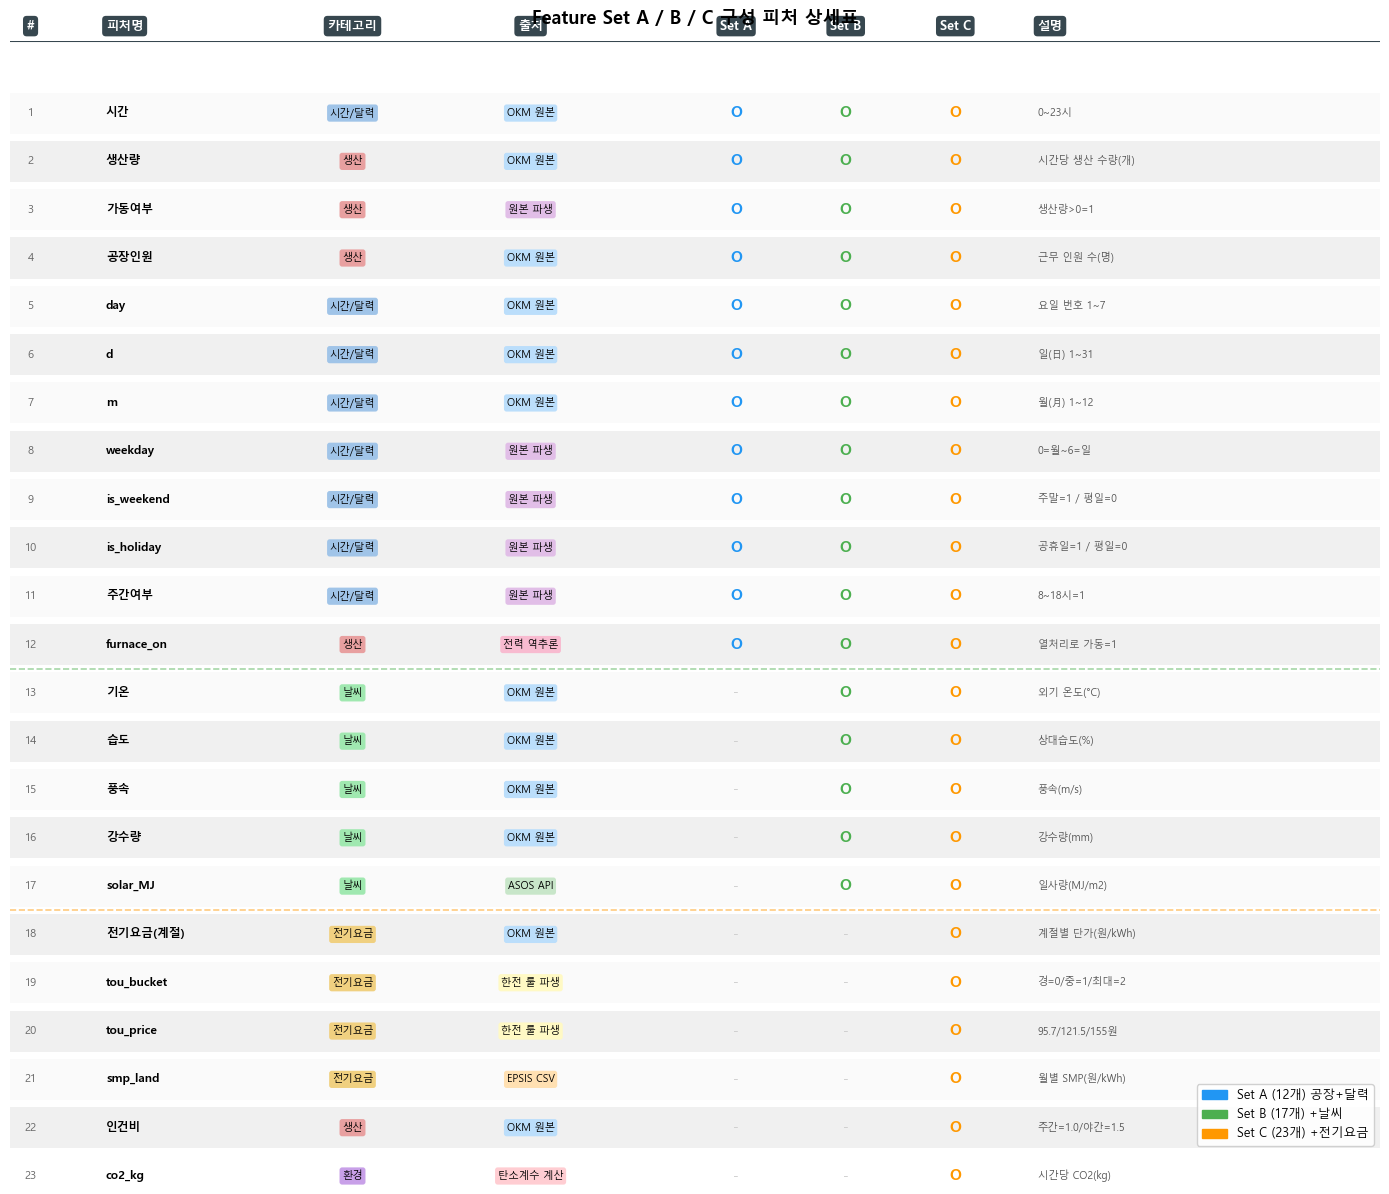

Feature Set 구성표 완료


In [108]:
# ================================================
# Feature Set A / B / C 구성표 시각화 (seaborn)
# ================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 데이터 정의 ───────────────────────────────────
feature_info = [
    ('시간',          '시간/달력', 'OKM 원본',    True,  True,  True,  '0~23시'),
    ('생산량',         '생산',    'OKM 원본',    True,  True,  True,  '시간당 생산 수량(개)'),
    ('가동여부',        '생산',    '원본 파생',   True,  True,  True,  '생산량>0=1'),
    ('공장인원',        '생산',    'OKM 원본',    True,  True,  True,  '근무 인원 수(명)'),
    ('day',           '시간/달력', 'OKM 원본',    True,  True,  True,  '요일 번호 1~7'),
    ('d',             '시간/달력', 'OKM 원본',    True,  True,  True,  '일(日) 1~31'),
    ('m',             '시간/달력', 'OKM 원본',    True,  True,  True,  '월(月) 1~12'),
    ('weekday',       '시간/달력', '원본 파생',   True,  True,  True,  '0=월~6=일'),
    ('is_weekend',    '시간/달력', '원본 파생',   True,  True,  True,  '주말=1 / 평일=0'),
    ('is_holiday',    '시간/달력', '원본 파생',   True,  True,  True,  '공휴일=1 / 평일=0'),
    ('주간여부',        '시간/달력', '원본 파생',   True,  True,  True,  '8~18시=1'),
    ('furnace_on',    '생산',    '전력 역추론',  True,  True,  True,  '열처리로 가동=1'),
    ('기온',           '날씨',    'OKM 원본',    False, True,  True,  '외기 온도(°C)'),
    ('습도',           '날씨',    'OKM 원본',    False, True,  True,  '상대습도(%)'),
    ('풍속',           '날씨',    'OKM 원본',    False, True,  True,  '풍속(m/s)'),
    ('강수량',          '날씨',    'OKM 원본',    False, True,  True,  '강수량(mm)'),
    ('solar_MJ',      '날씨',    'ASOS API',   False, True,  True,  '일사량(MJ/m2)'),
    ('전기요금(계절)',   '전기요금',  'OKM 원본',    False, False, True,  '계절별 단가(원/kWh)'),
    ('tou_bucket',    '전기요금',  '한전 룰 파생', False, False, True,  '경=0/중=1/최대=2'),
    ('tou_price',     '전기요금',  '한전 룰 파생', False, False, True,  '95.7/121.5/155원'),
    ('smp_land',      '전기요금',  'EPSIS CSV',  False, False, True,  '월별 SMP(원/kWh)'),
    ('인건비',          '생산',    'OKM 원본',    False, False, True,  '주간=1.0/야간=1.5'),
    ('co2_kg',        '환경',    '탄소계수 계산', False, False, True,  '시간당 CO2(kg)'),
]

labels   = [r[0] for r in feature_info]
cats     = [r[1] for r in feature_info]
sources  = [r[2] for r in feature_info]
set_a    = [r[3] for r in feature_info]
set_b    = [r[4] for r in feature_info]
set_c    = [r[5] for r in feature_info]
descs    = [r[6] for r in feature_info]
n = len(feature_info)

# ── 색상 정의 ─────────────────────────────────────
cat_colors = {
    '생산'    : '#E8A0A0',
    '시간/달력': '#A0C4E8',
    '날씨'    : '#A0E8B0',
    '전기요금' : '#F0D080',
    '환경'    : '#C8A0E8',
}
set_colors = {
    'A': '#2196F3',
    'B': '#4CAF50',
    'C': '#FF9800',
}

# ── 시각화 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, n - 0.5)
ax.axis('off')

col_x = {
    'num'    : 0.15,
    'feat'   : 0.7,
    'cat'    : 2.5,
    'source' : 3.8,
    'setA'   : 5.3,
    'setB'   : 6.1,
    'setC'   : 6.9,
    'desc'   : 7.5,
}

# 헤더
header_y = n - 0.2
for col, label, ha in [
    ('num',    '#',        'center'),
    ('feat',   '피처명',    'left'),
    ('cat',    '카테고리',  'center'),
    ('source', '출처',     'center'),
    ('setA',   'Set A',   'center'),
    ('setB',   'Set B',   'center'),
    ('setC',   'Set C',   'center'),
    ('desc',   '설명',     'left'),
]:
    ax.text(col_x[col], header_y, label, ha=ha, va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#37474F', ec='none'))

ax.axhline(n-0.5, color='#37474F', linewidth=1.5)

# 행 그리기
for i, row in enumerate(feature_info):
    feat, cat, src, sa, sb, sc, desc = row
    y = n - 2 - i

    # 배경
    bg = '#FAFAFA' if i % 2 == 0 else '#F0F0F0'
    ax.barh(y, 10, left=0, height=0.85, color=bg, zorder=0)

    # 번호
    ax.text(col_x['num'], y, str(i+1), ha='center', va='center', fontsize=8, color='#666')

    # 피처명
    ax.text(col_x['feat'], y, feat, ha='left', va='center', fontsize=8.5, fontweight='bold')

    # 카테고리 뱃지
    ax.text(col_x['cat'], y, cat, ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc=cat_colors.get(cat,'#EEE'), ec='none'))

    # 출처 뱃지
    src_color = {'OKM 원본':'#BBDEFB','원본 파생':'#E1BEE7',
                 'ASOS API':'#C8E6C9','한전 룰 파생':'#FFF9C4',
                 'EPSIS CSV':'#FFE0B2','탄소계수 계산':'#FFCDD2',
                 '전력 역추론':'#F8BBD0'}.get(src,'#EEE')
    ax.text(col_x['source'], y, src, ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25', fc=src_color, ec='none'))

    # Set A/B/C 체크
    for flag, col_key, color in [
        (sa, 'setA', set_colors['A']),
        (sb, 'setB', set_colors['B']),
        (sc, 'setC', set_colors['C']),
    ]:
        if flag:
            ax.text(col_x[col_key], y, 'O', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)
        else:
            ax.text(col_x[col_key], y, '-', ha='center', va='center',
                    fontsize=10, color='#CCCCCC')

    # 설명
    ax.text(col_x['desc'], y, desc, ha='left', va='center',
            fontsize=7.5, color='#555')

# 구분선 (Set B / Set C 경계)
ax.axhline(n-2-11.5, color='#4CAF50', linewidth=1.2, linestyle='--', alpha=0.5)
ax.axhline(n-2-16.5, color='#FF9800', linewidth=1.2, linestyle='--', alpha=0.5)

# 범례
legend_patches = [
    mpatches.Patch(color=set_colors['A'], label=f"Set A ({sum(set_a)}개) 공장+달력"),
    mpatches.Patch(color=set_colors['B'], label=f"Set B ({sum(set_b)}개) +날씨"),
    mpatches.Patch(color=set_colors['C'], label=f"Set C ({sum(set_c)}개) +전기요금"),
]
ax.legend(handles=legend_patches, loc='lower right',
          fontsize=9, framealpha=0.9)

plt.title('Feature Set A / B / C 구성 피처 상세표', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print("Feature Set 구성표 완료")

# Step 41 : 성능 비교표 시각화

  Feature Set A / B / C 정의

  Set_A (12개) : 공장 운영 + 달력 파생
  ['시간', '생산량', '가동여부', '공장인원', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', 'furnace_on']

  Set_B (17개) : Set_A + 실제 날씨
  추가 5개: ['기온', '습도', '풍속', '강수량', 'solar_MJ']

  Set_C (23개) : Set_B + 전기요금/비용 전체
  추가 6개: ['전기요금(계절)', 'tou_bucket', 'tou_price', 'smp_land', '인건비', 'co2_kg']


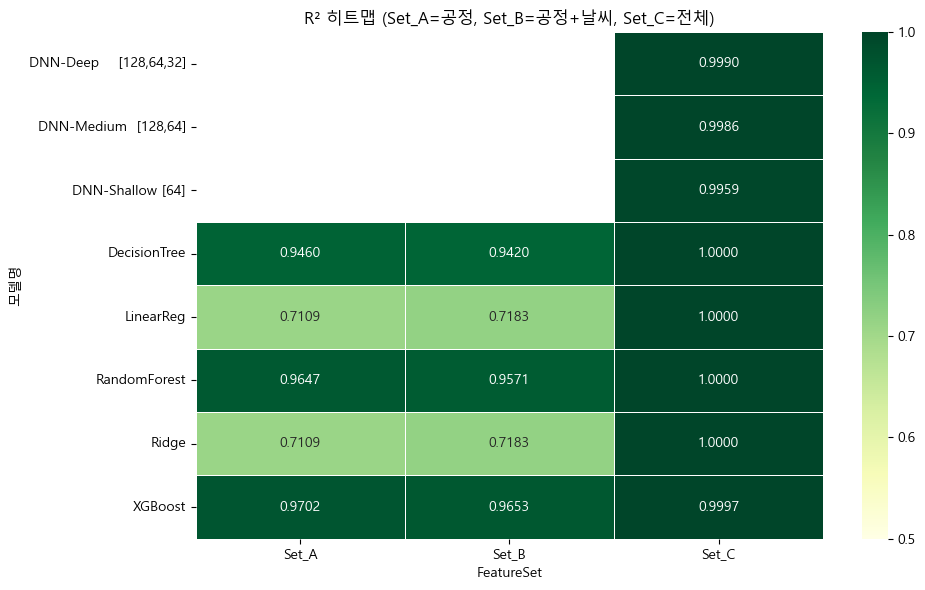

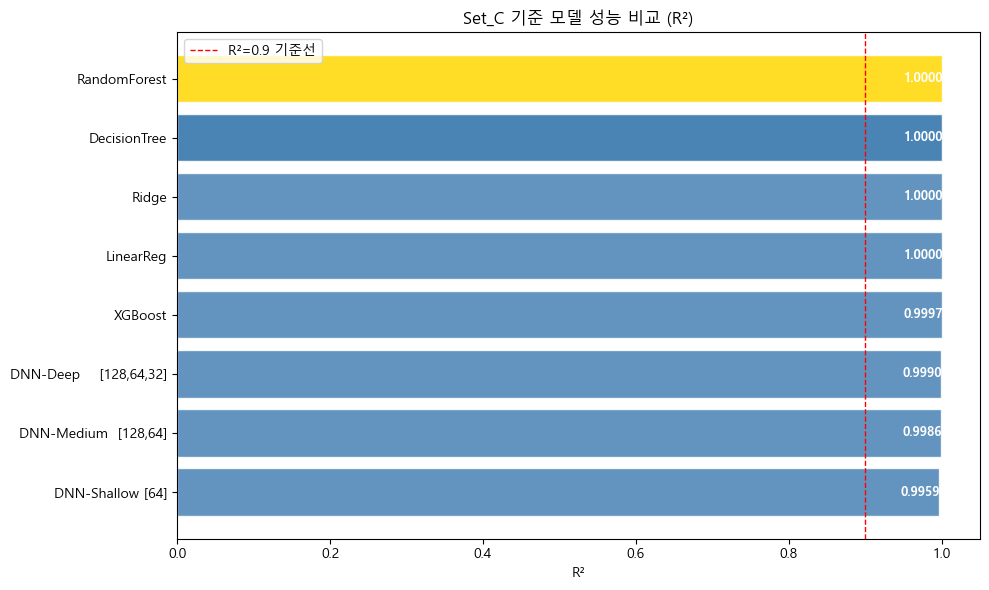

Step 41 완료


In [109]:
# ================================================
# Step 41: 성능 비교 시각화 (seaborn)
# ================================================

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

results_df_new = pd.DataFrame(all_results_new)

def clean_name(name):
    for s in ['[Set_A]','[Set_B]','[Set_C]']:
        name = name.replace(s,'').strip()
    return name

def get_set(name):
    if 'Set_A' in name: return 'Set_A'
    elif 'Set_B' in name: return 'Set_B'
    else: return 'Set_C'

results_df_new['모델명']     = results_df_new['모델'].apply(clean_name)
results_df_new['FeatureSet'] = results_df_new['모델'].apply(get_set)

# Feature Set 정의 출력
print("=" * 65)
print("  Feature Set A / B / C 정의")
print("=" * 65)
print(f"\n  Set_A ({len(FEATURE_SETS_NEW['Set_A'])}개) : 공장 운영 + 달력 파생")
print(f"  {FEATURE_SETS_NEW['Set_A']}")

set_b_added = [c for c in FEATURE_SETS_NEW['Set_B']
               if c not in FEATURE_SETS_NEW['Set_A']]
print(f"\n  Set_B ({len(FEATURE_SETS_NEW['Set_B'])}개) : Set_A + 실제 날씨")
print(f"  추가 {len(set_b_added)}개: {set_b_added}")

set_c_added = [c for c in FEATURE_SETS_NEW['Set_C']
               if c not in FEATURE_SETS_NEW['Set_B']]
print(f"\n  Set_C ({len(FEATURE_SETS_NEW['Set_C'])}개) : Set_B + 전기요금/비용 전체")
print(f"  추가 {len(set_c_added)}개: {set_c_added}")
print("=" * 65)

# R² 히트맵
pivot = results_df_new.pivot_table(
    index='모델명', columns='FeatureSet', values='R²').round(4)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            annot_kws={'size':10})
ax.set_title('R² 히트맵 (Set_A=공정, Set_B=공정+날씨, Set_C=전체)', fontsize=12)
plt.tight_layout()
plt.show()

# Set_C R² 막대
setC_new = results_df_new[
    results_df_new['모델'].str.contains('Set_C')
].sort_values('R²', ascending=True).copy()

fig2, ax2 = plt.subplots(figsize=(10, 6))
colors = ['gold' if i==len(setC_new)-1 else 'steelblue'
          for i in range(len(setC_new))]
ax2.barh(setC_new['모델명'], setC_new['R²'],
         color=colors, edgecolor='white', alpha=0.85)
ax2.set_xlabel('R²')
ax2.set_title('Set_C 기준 모델 성능 비교 (R²)')
ax2.axvline(0.9, color='red', linestyle='--', linewidth=1, label='R²=0.9 기준선')
ax2.legend()
for i, val in enumerate(setC_new['R²']):
    ax2.text(val-0.05, i, f'{val:.4f}', va='center',
             fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print("Step 41 완료")

# Step 42 : 하이퍼파라미터 튜닝 (RF + XGBoost)

In [110]:
# ================================================
# Step 42: 하이퍼파라미터 튜닝 (RF + XGBoost)
# n_jobs=1 (Windows 안정) / 약 5~10분 소요
# ================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

Xtr = splits_new['Set_C']['X_train']
Xte = splits_new['Set_C']['X_test']

# RF 튜닝
print("RF 튜닝 중... (3~5분)")
rf_tuned_new = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [10, 15, 20, None],
        'min_samples_leaf': [1, 3, 5],
        'max_features'    : ['sqrt', 'log2'],
    },
    n_iter=10, cv=3, scoring='r2',
    random_state=42, n_jobs=1, verbose=1
)
rf_tuned_new.fit(Xtr, y_train)
y_pred_rf = rf_tuned_new.predict(Xte)
res_rf = evaluate_model('RF_Tuned [Set_C]', y_test, y_pred_rf)
all_results_new.append(res_rf)
print(f"RF 최적 파라미터: {rf_tuned_new.best_params_}")
print(f"RF 결과: RMSE={res_rf['RMSE']} | MAE={res_rf['MAE']} | R²={res_rf['R²']}")

# XGB 튜닝
print("\nXGB 튜닝 중... (3~5분)")
xgb_tuned_new = RandomizedSearchCV(
    estimator = XGBRegressor(random_state=42, verbosity=0, n_jobs=1),
    param_distributions = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [4, 6, 8],
        'learning_rate'   : [0.05, 0.1, 0.2],
        'subsample'       : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=10, cv=3, scoring='r2',
    random_state=42, n_jobs=1, verbose=1
)
xgb_tuned_new.fit(Xtr, y_train)
y_pred_xgb = xgb_tuned_new.predict(Xte)
res_xgb = evaluate_model('XGB_Tuned [Set_C]', y_test, y_pred_xgb)
all_results_new.append(res_xgb)
print(f"XGB 최적 파라미터: {xgb_tuned_new.best_params_}")
print(f"XGB 결과: RMSE={res_xgb['RMSE']} | MAE={res_xgb['MAE']} | R²={res_xgb['R²']}")

# 튜닝 전후 비교
print("\n=== 튜닝 전후 비교 ===")
before_rf  = [r for r in all_results_new if r['모델']=='RandomForest [Set_C]']
before_xgb = [r for r in all_results_new if r['모델']=='XGBoost [Set_C]']
if before_rf:
    b = before_rf[0]
    print(f"RF  튜닝 전: RMSE={b['RMSE']} R²={b['R²']}")
    print(f"RF  튜닝 후: RMSE={res_rf['RMSE']} R²={res_rf['R²']}")
if before_xgb:
    b = before_xgb[0]
    print(f"XGB 튜닝 전: RMSE={b['RMSE']} R²={b['R²']}")
    print(f"XGB 튜닝 후: RMSE={res_xgb['RMSE']} R²={res_xgb['R²']}")

print("\nStep 42 완료")

RF 튜닝 중... (3~5분)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF 최적 파라미터: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
RF 결과: RMSE=4.26 | MAE=2.6 | R²=0.9939

XGB 튜닝 중... (3~5분)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGB 최적 파라미터: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGB 결과: RMSE=0.56 | MAE=0.18 | R²=0.9999

=== 튜닝 전후 비교 ===
RF  튜닝 전: RMSE=0.17 R²=1.0
RF  튜닝 후: RMSE=4.26 R²=0.9939
XGB 튜닝 전: RMSE=0.91 R²=0.9997
XGB 튜닝 후: RMSE=0.56 R²=0.9999

Step 42 완료


# Step 43 : 최종 모델 저장 (pipeline.pkl)

In [111]:
# ================================================
# Step 43: 최종 모델 저장 (pipeline.pkl)
# ================================================

import joblib
import os
from sklearn.pipeline import Pipeline

os.makedirs('./models', exist_ok=True)

# 튜닝 결과 중 더 좋은 모델 선택
if res_rf['R²'] >= res_xgb['R²']:
    best_model_tuned = rf_tuned_new.best_estimator_
    best_params_new  = rf_tuned_new.best_params_
    best_model_name  = 'RandomForest'
    print(f"최종 선택: Random Forest (R²={res_rf['R²']})")
else:
    best_model_tuned = xgb_tuned_new.best_estimator_
    best_params_new  = xgb_tuned_new.best_params_
    best_model_name  = 'XGBoost'
    print(f"최종 선택: XGBoost (R²={res_xgb['R²']})")

# 파이프라인 구성
final_pipeline_new = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  best_model_tuned)
])

# Set_C 피처로 재학습
final_pipeline_new.fit(splits_new['Set_C']['X_train'], y_train)

# 저장
save_path_new = './models/energy_pipeline_v2.pkl'
joblib.dump({
    'pipeline'    : final_pipeline_new,
    'feature_cols': FEATURE_SETS_NEW['Set_C'],
    'scaler'      : scalers_new['Set_C'],
    'best_params' : best_params_new,
    'model_name'  : best_model_name,
    'feature_sets': FEATURE_SETS_NEW,
}, save_path_new)

size_mb = os.path.getsize(save_path_new) / (1024**2)
print(f"저장 완료: {save_path_new} ({size_mb:.2f} MB)")

# 로드 후 검증
loaded_new = joblib.load(save_path_new)
y_check    = loaded_new['pipeline'].predict(splits_new['Set_C']['X_test'])
from sklearn.metrics import r2_score
print(f"로드 후 R² 검증: {r2_score(y_test, y_check):.4f}")
print("Step 43 완료")

최종 선택: XGBoost (R²=0.9999)
저장 완료: ./models/energy_pipeline_v2.pkl (0.65 MB)
로드 후 R² 검증: 0.9999
Step 43 완료


# Step 44 : Streamlit app.py 생성

In [112]:
# ================================================
# Step 44: Streamlit app.py 생성 (최종본)
# furnace_on 추가 반영
# ================================================

import os, shutil

os.makedirs('./energy_app', exist_ok=True)
os.makedirs('./energy_app/models', exist_ok=True)

shutil.copy('./models/energy_pipeline_v2.pkl',
            './energy_app/models/energy_pipeline_v2.pkl')

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="에너지 피크 예측 시스템",
    page_icon="",
    layout="wide"
)

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 모델 로드 ─────────────────────────────────────
MODEL_PATH = os.path.join(os.path.dirname(__file__), "models", "energy_pipeline_v2.pkl")

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

loaded       = load_model()
pipeline     = loaded["pipeline"]
feature_cols = loaded["feature_cols"]

# ── 상수 정의 ─────────────────────────────────────
def get_tou_bucket(month, hour):
    if hour >= 22 or hour <= 7: return 0
    if month in [6,7,8]:
        return 2 if hour in [11,12,13,14,15,16,17] else 1
    elif month in [11,12,1,2]:
        return 2 if hour in [10,17,18,19,20] else 1
    return 1

TOU_PRICE       = {0: 95.7, 1: 121.5, 2: 155.0}
TOU_LABEL       = {0:"경부하 (95.7원/kWh)", 1:"중간부하 (121.5원/kWh)", 2:"최대부하 (155.0원/kWh)"}
EMISSION_FACTOR = 0.4153
MONTH_NAMES     = ["1월","2월","3월","4월","5월","6월","7월","8월","9월","10월","11월","12월"]
DAY_MAP         = {"월":1,"화":2,"수":3,"목":4,"금":5,"토":6,"일":7}
SMP_2021        = {1:70.47,2:75.25,3:83.78,4:75.97,5:78.93,
                   6:82.72,7:87.04,8:93.41,9:98.21,10:107.53,11:126.83,12:142.46}
HOLIDAYS        = [20210101,20210212,20210301,20210505,20210519,
                   20210606,20210815,20210920,20210921,20210922,20211003]

# ── 타이틀 ───────────────────────────────────────
st.title("제조 공장 피크 전력 예측 시스템")
st.caption("KAMP 자원 최적화 AI | 선박 부품 제조 공장 | 올라운더팀")
st.divider()

# ── 사이드바 ──────────────────────────────────────
st.sidebar.header("공정 파라미터 입력")
st.sidebar.divider()

st.sidebar.subheader("시간 / 날짜")
hour     = st.sidebar.slider("시간 (0~23시)", 0, 23, 10)
month    = st.sidebar.selectbox("월", MONTH_NAMES, index=4)
day_name = st.sidebar.selectbox("요일", list(DAY_MAP.keys()), index=0)
date_d   = st.sidebar.slider("일 (1~31)", 1, 31, 15)

st.sidebar.divider()
st.sidebar.subheader("생산 조건")
production  = st.sidebar.slider("생산량", 0, 9830, 200, step=10)
workers     = st.sidebar.slider("공장 인원", 0.0, 48.0, 5.0, step=0.5)
labor_cost  = st.sidebar.radio("근무 유형",
                                options=[1.0, 1.5],
                                format_func=lambda x: "주간(1.0)" if x==1.0 else "야간(1.5)")
furnace     = st.sidebar.radio("열처리로 상태",
                                options=[0, 1],
                                format_func=lambda x: "OFF(휴지)" if x==0 else "ON(가동)")

st.sidebar.divider()
st.sidebar.subheader("날씨 조건")
temperature = st.sidebar.slider("기온 (°C)", -20, 40, 20)
humidity    = st.sidebar.slider("습도 (%)", 0, 100, 60)
wind_speed  = st.sidebar.slider("풍속 (m/s)", 0.0, 10.0, 2.0, step=0.1)
rainfall    = st.sidebar.slider("강수량 (mm)", 0.0, 150.0, 0.0, step=0.5)
solar       = st.sidebar.slider("일사량 (MJ/m2)", 0.0, 4.0, 1.0, step=0.1)

st.sidebar.divider()
st.sidebar.subheader("전기요금")
tariff_options = {
    "겨울 (109.8원/kWh)": 109.8,
    "봄가을 (167.2원/kWh)": 167.2,
    "여름 (191.6원/kWh)": 191.6,
}
season_label = st.sidebar.selectbox("계절별 단가", list(tariff_options.keys()), index=1)
tariff       = tariff_options[season_label]

# ── 입력값 계산 ───────────────────────────────────
m_num       = MONTH_NAMES.index(month) + 1
weekday_num = DAY_MAP[day_name] - 1
is_weekend  = 1 if weekday_num >= 5 else 0
is_holiday  = 1 if int(f"2021{m_num:02d}{date_d:02d}") in HOLIDAYS else 0
is_working  = 1 if production > 0 else 0
is_daytime  = 1 if (8 <= hour <= 18) else 0
tou         = get_tou_bucket(m_num, hour)
tou_price   = TOU_PRICE[tou]
smp         = SMP_2021.get(m_num, 87.0)

input_dict = {
    "시간"         : hour,
    "생산량"        : production,
    "가동여부"       : is_working,
    "공장인원"       : workers,
    "day"          : DAY_MAP[day_name],
    "d"            : date_d,
    "m"            : m_num,
    "weekday"      : weekday_num,
    "is_weekend"   : is_weekend,
    "is_holiday"   : is_holiday,
    "주간여부"       : is_daytime,
    "furnace_on"   : furnace,
    "기온"          : temperature,
    "습도"          : humidity,
    "풍속"          : wind_speed,
    "강수량"         : rainfall,
    "solar_MJ"     : solar,
    "전기요금(계절)"  : tariff,
    "tou_bucket"   : tou,
    "tou_price"    : tou_price,
    "smp_land"     : smp,
    "인건비"         : labor_cost,
    "co2_kg"       : 0.0,
}

input_df  = pd.DataFrame([input_dict])[feature_cols]
pred_kw   = float(pipeline.predict(input_df)[0])
pred_kw   = max(0, pred_kw)
co2_val   = round(pred_kw / 1000 * EMISSION_FACTOR * 1000, 4)

# 위험 등급
if pred_kw < 70:
    grade, color = "안전", "green"
elif pred_kw < 110:
    grade, color = "보통", "blue"
elif pred_kw < 150:
    grade, color = "주의", "orange"
else:
    grade, color = "위험", "red"

# ── KPI 카드 ──────────────────────────────────────
col1, col2, col3, col4, col5, col6 = st.columns(6)
with col1:
    st.metric("예측 피크전력", f"{pred_kw:.1f} kW",
              delta=f"{pred_kw-90:+.1f} kW")
with col2:
    st.metric("위험 등급", grade)
with col3:
    st.metric("TOU 구간", TOU_LABEL[tou])
with col4:
    st.metric("SMP 단가", f"{smp:.2f} 원/kWh")
with col5:
    st.metric("탄소 배출", f"{co2_val:.3f} kg CO2")
with col6:
    furnace_label = "ON (가동중)" if furnace==1 else "OFF (휴지)"
    st.metric("열처리로", furnace_label)

st.divider()

# ── 차트 ──────────────────────────────────────────
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("피크전력 게이지")
    fig, ax = plt.subplots(figsize=(6, 3))
    zones    = [70, 110, 150, 210]
    colors_z = ["#2ecc71","#3498db","#f39c12","#e74c3c"]
    prev = 0
    for z, c in zip(zones, colors_z):
        ax.barh(0, z-prev, left=prev, height=0.5, color=c, alpha=0.4)
        prev = z
    ax.axvline(pred_kw, color=color, linewidth=4, label=f"예측 {pred_kw:.1f}kW")
    ax.axvline(90, color="gray", linewidth=1.5, linestyle="--", label="평균 90kW")
    ax.set_xlim(0, 220)
    ax.set_yticks([])
    ax.set_xlabel("피크전력 (kW)")
    ax.legend()
    ax.set_title(f"현재 예측: {pred_kw:.1f} kW [{grade}]")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

with col_right:
    st.subheader("24시간 시뮬레이션")
    hourly_preds = []
    for h in range(24):
        row = input_dict.copy()
        row["시간"]       = h
        row["주간여부"]    = 1 if (8<=h<=18) else 0
        row["tou_bucket"] = get_tou_bucket(m_num, h)
        row["tou_price"]  = TOU_PRICE[row["tou_bucket"]]
        row["co2_kg"]     = 0.0
        df_h = pd.DataFrame([row])[feature_cols]
        hourly_preds.append(max(0, float(pipeline.predict(df_h)[0])))

    fig2, ax2 = plt.subplots(figsize=(6, 3))
    bar_cols = [color if h==hour else "steelblue" for h in range(24)]
    ax2.bar(range(24), hourly_preds, color=bar_cols, alpha=0.8, edgecolor="white")
    ax2.axhline(130, color="orange", linestyle="--", linewidth=1.5, label="고피크 130kW")
    ax2.axhline(90,  color="gray",   linestyle=":",  linewidth=1.2, label="평균 90kW")
    ax2.set_xlabel("시간 (시)")
    ax2.set_ylabel("예측 피크전력 (kW)")
    ax2.set_xticks(range(24))
    ax2.legend()
    ax2.set_title("24시간 피크전력 시뮬레이션")
    plt.tight_layout()
    st.pyplot(fig2)
    plt.close()

st.divider()

# ── 조치 가이드 ───────────────────────────────────
st.subheader("운영 조치 가이드")
if grade == "안전":
    st.success(f"안전 구간 -- 현재 조건을 유지하세요. 예측 피크: {pred_kw:.1f}kW")
elif grade == "보통":
    st.info(f"보통 구간 -- 정상 운영 중입니다. 예측 피크: {pred_kw:.1f}kW")
elif grade == "주의":
    st.warning(f"""주의 구간 -- 피크 상승 가능성. 예측 피크: {pred_kw:.1f}kW

권장 조치
- 생산량 일부를 경부하(22시 이후)로 분산
- 불필요한 설비 대기 모드 전환
- 열처리로 가동 시점 재조정""")
else:
    st.error(f"""위험 구간 -- 즉각 조치 필요! 예측 피크: {pred_kw:.1f}kW

즉각 조치
- 열처리로 추가 가동 중단
- 생산량 {int(production*0.8):,}개 이하 조정 권장
- 한전 피크 관리 담당자 즉시 보고""")

st.divider()

# ── ESG 탄소 배출 ─────────────────────────────────
st.subheader("ESG 탄소 배출 현황")
col_e1, col_e2, col_e3 = st.columns(3)
with col_e1:
    st.metric("시간당 탄소 배출", f"{co2_val:.3f} kg CO2")
with col_e2:
    st.metric("일간 예상 배출", f"{co2_val*24:.2f} kg CO2")
with col_e3:
    st.metric("연간 추정 배출", f"{co2_val*24*365/1000:.2f} tCO2")

with st.expander("현재 입력값 상세 보기"):
    display_df = pd.DataFrame({
        "항목": ["시간","월","일","요일","생산량","공장인원","근무유형","열처리로",
                 "기온","습도","풍속","강수량","일사량","전기요금","TOU구간","SMP"],
        "입력값": [f"{hour}시", month, f"{date_d}일", day_name,
                  f"{production:,}", f"{workers:.1f}명",
                  "주간" if labor_cost==1.0 else "야간",
                  "ON" if furnace==1 else "OFF",
                  f"{temperature}°C", f"{humidity}%",
                  f"{wind_speed}m/s", f"{rainfall}mm",
                  f"{solar}MJ/m2", f"{tariff}원/kWh",
                  TOU_LABEL[tou], f"{smp:.2f}원/kWh"]
    })
    st.dataframe(display_df, use_container_width=True, hide_index=True)

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py 생성 완료")
print("터미널 실행:")
print("  conda activate ml_edu")
print("  cd C:\\Users\\Admin\\hipython\\ml\\energy_app")
print("  streamlit run app.py")

app.py 생성 완료
터미널 실행:
  conda activate ml_edu
  cd C:\Users\Admin\hipython\ml\energy_app
  streamlit run app.py
